# 12 — Population & Portraits : le Congrès en images

**Un livrable de communication, pas une nouvelle recherche.** Le verdict *« copier les élus ne bat pas le
marché »* est déjà verrouillé par les notebooks 05b / 07 / 09. Ici on **montre la donnée** : une vue globale de
la population, des portraits de membres intéressants avec leurs stats, et le paysage des benchmarks vendus au
public.

**100 % autonome** : on recopie le moteur (prix → reconstruction FIFO → rendements time-weighted) et on
**recalcule tout** ; les tables propres du nb09 ne servent que d'**oracle de contrôle**. Chaque figure est
exportée en PNG dans `docs/figs_pop/` pour les slides.

**Le fil** — A · la population → B · les portraits → C · hype & benchmarks.

*Règle de lecture (chef de recherche) : une idée par figure, ≤ 3 chiffres légendés, les choix explicités.*

## §0 — Le moteur autonome (silencieux)

On reconstruit chaque portefeuille à partir des seules transactions déclarées : entrée au 1ᵉʳ jour coté ≥ date du
trade, comptabilité **FIFO** (jamais de position courte), puis **rendement en parts** (time-weighted : un apport
n'est jamais une performance). Code repris tel quel des nb 05b/07/09.

In [1]:
# === COPIE EXACTE 05b — cellule 2 (ne pas modifier : garantit l'équivalence) ===
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [2]:
# --- charte figures & dossier de sortie ---
FIGS = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/docs/figs_pop"
os.makedirs(FIGS, exist_ok=True)
FIG = lambda n: os.path.join(FIGS, n + ".png")
# palette cohérente : achat vert · vente rouge · SPY noir · membre bleu
C_BUY, C_SELL, C_SPY, C_M = "tab:green", "tab:red", "k", "tab:blue"
print("figures ->", FIGS)

figures -> /Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/docs/figs_pop


In [3]:
# === COPIE EXACTE 05b — cellule 3 (ne pas modifier : garantit l'équivalence) ===
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")
_n2013 = int((df["traded"].dt.year == 2013).sum())
print(f"dont {_n2013} trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y")

134464 -> 134429 trades  |  372 membres  |  4618 tickers
dont 743 trades exécutés en 2013 (déclarés dans des dépôts 2014+) — gardés : chaque coupe classe sur tout l'historique ≤ 31/12/Y


In [4]:
# === COPIE EXACTE 05b — cellule 5 (ne pas modifier : garantit l'équivalence) ===
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [5]:
# NB : la cellule de téléchargement yfinance (05b cell 6) est SAUTÉE — le cache prices_v2
# est complet (3 351 tickers). Décommenter le nb07 cell 6 pour rafraîchir en ligne.

In [6]:
# === COPIE EXACTE 05b — cellule 7 (ne pas modifier : garantit l'équivalence) ===
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


In [7]:
# === COPIE EXACTE 05b — cellule 9 (ne pas modifier : garantit l'équivalence) ===
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [8]:
# === COPIE EXACTE 05b — cellule 14 (ne pas modifier : garantit l'équivalence) ===
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [9]:
# === COPIE EXACTE 05b — cellule 10 (ne pas modifier : garantit l'équivalence) ===
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Nancy Pelosi"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

In [10]:
# === COPIE EXACTE 05b — cellule 16 (ne pas modifier : garantit l'équivalence) ===
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


In [11]:
# dfx = table canonique (37 col. avec owner_n/name_canon), MÊME périmètre que df (motif du §16 du 05b)
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
_raw = pd.read_csv(CLEAN, low_memory=False)
dfx = (_raw.drop(columns=["ticker"])
           .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                            "direction": "op", "transaction_date": "traded",
                            "amount_midpoint": "size_usd"}))
dfx["traded"] = pd.to_datetime(dfx["traded"], errors="coerce")
dfx["disclosure_date"] = pd.to_datetime(dfx["disclosure_date"], errors="coerce")
dfx = dfx[dfx["traded"].dt.year.between(2013, 2026)]
dfx = dfx[dfx["ticker"].isin(set(need))].reset_index(drop=True)
assert len(dfx) == len(df), (len(dfx), len(df))

# owner normalisé (mapping OWNER17 du 05b) + nom canonique par bioguide
OWNER = {"Spouse":"conjoint","SP":"conjoint","SELF":"élu","Self":"élu",
         "JT":"joint","Joint Tenancy":"joint","Joint":"joint",
         "Dependent Child":"enfant","DC":"enfant","Child":"enfant"}
dfx["owner_n"] = dfx["owner"].map(OWNER)
_name_canon = dfx.groupby("bioguide_id")["name"].agg(lambda s: s.mode().iloc[0])
dfx["name_canon"] = dfx["bioguide_id"].map(_name_canon)
print(f"dfx : {len(dfx)} trades × {dfx.shape[1]} colonnes | owner_n couvert : {dfx.owner_n.notna().mean():.0%} | "
      f"{dfx.bioguide_id.nunique()} membres")

dfx : 118029 trades × 37 colonnes | owner_n couvert : 100% | 359 membres


### §0.2 — Profil par membre (`beh`) et mesures de marché

`beh` = une ligne par membre reconstruit (266). On y ajoute la concentration (part de la plus grosse position),
puis les mesures de marché (β, α, IR) et le track-record par trade (hit-rate, profit factor).

In [12]:
# jointure ancienneté (table_congres) + leadership (fichier daté), agrégation PAR bioguide_id
_tc = pd.read_csv("/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/table_congres_2014_2026.csv", low_memory=False)
_yio = _tc.dropna(subset=["bioguide_id"]).groupby("bioguide_id")["years_in_office"].max()
_lead = pd.read_csv(os.path.join(BASE, "leadership_2014_2026.csv"))
_leaders = set(_lead["bioguide_id"]) & set(wf_ret)

def _mode(s):
    m = s.mode(); return m.iloc[0] if len(m) else np.nan
_agg = dfx.groupby("bioguide_id")
beh = pd.DataFrame({
    "name": _agg["name_canon"].first(),
    "party": _agg["party"].agg(_mode), "chamber": _agg["chamber"].agg(_mode),
    "n_trades": _agg.size(),
    "buy_share": _agg["op"].agg(lambda s: (s=="buy").mean()),
    "taille_med": _agg["size_usd"].median(),
    "pct_1re_fourchette": _agg["size_usd"].agg(lambda s: (s<=8000.5).mean()),
    "lag_med": _agg["lag_days"].median(),
    "owner_dom": _agg["owner_n"].agg(_mode),
    "conjoint_share": _agg["owner_n"].agg(lambda s: (s=="conjoint").mean()),
    "n_tickers": _agg["ticker"].nunique(),
    "sect_dom": _agg["sector_gics"].agg(_mode),
})
beh["years_in_office"] = beh.index.map(_yio)
beh["leader"] = beh.index.isin(_leaders)
beh["n_days"] = beh.index.map({b: len(r) for b, r in wf_ret.items()})
_st = {b: stats(r) for b, r in wf_ret.items()}
for _k in ("sharpe", "vol", "cagr", "maxdd"):
    beh[_k] = beh.index.map({b: s[_k] for b, s in _st.items()})
beh = beh[beh.index.isin(wf_ret)].copy()          # les 266 reconstruits
beh["eligible"] = (beh.n_trades >= 10) & (beh.n_days >= 126)
print(f"beh : {len(beh)} membres ({beh.eligible.sum()} éligibles) | {beh.leader.sum()} leaders | "
      f"ancienneté connue : {beh.years_in_office.notna().mean():.0%}")
beh.sort_values("n_trades", ascending=False).head(6)[["name","party","chamber","n_trades","buy_share","conjoint_share","n_tickers","sharpe"]].round(2)

beh : 266 membres (223 éligibles) | 8 leaders | ancienneté connue : 89%


,name,party,chamber,n_trades,buy_share,conjoint_share,n_tickers,sharpe
bioguide_id,,,,,,,,
K000389,Rohit Khanna,Democrat,house,32684,0.57,0.65,975,0.87
M001157,Michael T. McCaul,Republican,house,16028,0.46,0.55,582,0.61
R000586,James B. Renacci,Republican,house,3978,0.54,0.00,557,0.71
G000583,Josh Gottheimer,Democrat,house,3054,0.41,0.00,478,0.78
R000582,David P. Roe,Republican,house,3003,0.42,0.01,407,0.84
M001193,Thomas MacArthur,Republican,house,2617,0.53,0.00,435,0.70


In [13]:
# --- mesures relatives au marché (nb09 §1) ---
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan
def alpha_beta(r):
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))
def sortino(r):
    d = r.dropna(); dn = d[d < 0].std()
    return d.mean() / dn * np.sqrt(252) if dn > 0 else np.nan
def exces_spy(bid):
    r = wf_ret[bid]; nav = (1+r).cumprod(); cagr = nav.iloc[-1]**(252/len(r))-1
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod(); cagrs = navs.iloc[-1]**(252/len(rs))-1
    return cagr - cagrs
print("mesures prêtes : info_ratio, alpha_beta, sortino, exces_spy")

mesures prêtes : info_ratio, alpha_beta, sortino, exces_spy


In [14]:
# --- concentration : HHI, N_eff, top1 par membre (le graphe est en Partie A) ---
def concentration(bid):
    g = df[df.bioguide_id == bid]; N = member_shares(g)
    if N is None: return None
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    V = (N*P).sum(axis=1); act = V > 0
    if act.sum() == 0: return None
    W = (N*P).div(V, axis=0)[act]
    hhi = (W**2).sum(axis=1).mean(); top1 = W.max(axis=1).mean()
    return dict(hhi=hhi, n_eff=1/hhi if hhi>0 else np.nan, top1=top1, n_pos_moy=(N[act]>0).sum(axis=1).mean())
_conc = pd.DataFrame({b: v for b, v in ((b, concentration(b)) for b in wf_ret) if v}).T
beh = beh.join(_conc)
print(f"plus grosse position moyenne {beh.top1.mean():.0%} (concentration = mesure simple retenue)")

plus grosse position moyenne 45% (concentration = mesure simple retenue)


In [15]:
# --- risque/perf par membre -> beh (nb09 §7) ---
_rows = {}
for b, r in wf_ret.items():
    st = stats(r); ab = alpha_beta(r); T = len(r)
    _rows[b] = dict(sortino=sortino(r),
                    t_sharpe=st["sharpe"] * np.sqrt(T / 252) if np.isfinite(st["sharpe"]) else np.nan,
                    ir=info_ratio(r), beta=ab["beta"], alpha_ann=ab["alpha_ann"],
                    appraisal=ab["appraisal"], t_appr=ab["t_appr"], exces_cagr_spy=exces_spy(b))
_perf = pd.DataFrame(_rows).T
_perf["t_ir"] = _perf["ir"] * np.sqrt(beh["n_days"].reindex(_perf.index) / 252)
for c in _perf.columns: beh[c] = _perf[c]
print(f"beta médian {beh.beta.median():.2f} | appraisal>0 (éligibles) {(beh[beh.eligible].appraisal>0).mean():.0%}")

beta médian 0.97 | appraisal>0 (éligibles) 44%


In [16]:
from collections import deque
LAST_DAY = cal.max()
def fifo_holding(g):
    closed, opened = [], []          # (durée_j, parts) fermés ; (durée_censurée_j, parts) ouverts
    for tk, gt in g.groupby("ticker"):
        lots = deque()
        for _, row in gt.sort_values("traded").iterrows():        # MÊME tri que member_shares (garantit la conservation)
            dd, p = eff_price(tk, row["traded"])
            if dd is None: continue
            q = row["size_usd"] / p
            if row["op"] == "buy":
                lots.append([dd, q])
            else:
                held = sum(l[1] for l in lots); qv = min(q, held); take_tot = qv
                while take_tot > 1e-12 and lots:
                    tau_b, parts = lots[0]; take = min(parts, take_tot)
                    closed.append(((dd - tau_b).days, take)); take_tot -= take
                    if parts - take <= 1e-12: lots.popleft()
                    else: lots[0][1] = parts - take
        for tau_b, parts in lots:
            if parts > 1e-9:
                opened.append(((LAST_DAY - tau_b).days, parts))
    return closed, opened
# passe sur tous les membres
_CL, _OP = [], []
_open_by_mt = {}
for b in wf_ret:
    c, o = fifo_holding(df[df.bioguide_id == b]); _CL += c; _OP += o
closed = pd.DataFrame(_CL, columns=["duree","parts"]); opened = pd.DataFrame(_OP, columns=["duree","parts"])
_dur_med = np.median(np.repeat(closed.duree.values, np.maximum(1,(closed.parts.values/closed.parts.min()).round().astype(int).clip(max=50))))
_pct_open = opened.parts.sum() / (closed.parts.sum() + opened.parts.sum())
print(f"épisodes fermés : {len(closed)} | encore ouverts (censurés) : {len(opened)} | "
      f"part des parts achetées encore détenues à fin 2026 : {_pct_open:.0%}")

épisodes fermés : 61963 | encore ouverts (censurés) : 28944 | part des parts achetées encore détenues à fin 2026 : 44%


In [17]:
# --- track record par trade -> beh (nb09 §8) ---
_b = dfx[dfx.op == "buy"][["bioguide_id", "ticker", "traded"]].sort_values("traded").reset_index()
_s = (dfx[dfx.op == "sell"][["bioguide_id", "ticker", "traded"]].dropna()
      .sort_values("traded").rename(columns={"traded": "sortie_vente"}))
_paires = pd.merge_asof(_b, _s, left_on="traded", right_on="sortie_vente",
                        by=["bioguide_id", "ticker"], direction="forward", allow_exact_matches=False)
_b["sortie_vente"] = _paires["sortie_vente"].values
px = pd.DataFrame(prices); PXV = px.to_numpy(); SPYV = spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}
_last_true = {}
for tk in need:
    _d = pd.read_csv(os.path.join(PRICES, tk + ".csv"), usecols=["Date"])["Date"]
    _last_true[tk] = cal.searchsorted(pd.Timestamp(_d.iloc[-1]), side="right") - 1
_LAST = np.array([_last_true[tk] for tk in px.columns]); HOLD_MAX = 252
i0 = cal.searchsorted(pd.DatetimeIndex(_b["traded"]), side="right")
i_v = cal.searchsorted(pd.DatetimeIndex(pd.Series(_b["sortie_vente"]).fillna(cal[-1])), side="right")
i1 = np.where(_b["sortie_vente"].isna(), i0 + HOLD_MAX, np.minimum(i_v, i0 + HOLD_MAX))
i1 = np.minimum(np.maximum(i1, i0 + 1), len(cal) - 1)
cols = np.array([COL.get(t, -1) for t in _b["ticker"]])
ok = (cols >= 0) & (i0 < len(cal) - 1) & (i0 <= _LAST[np.maximum(cols, 0)])
x = np.full(len(_b), np.nan); xr = np.full(len(_b), np.nan)
r_, c0, c1 = cols[ok], i0[ok], np.asarray(i1)[ok]
p0, p1 = PXV[c0, r_], PXV[c1, r_]; b0, b1 = SPYV[c0], SPYV[c1]
valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0) & (b0 > 0)
_res = np.full(int(ok.sum()), np.nan); _resr = np.full(int(ok.sum()), np.nan)
_res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1); _resr[valid] = p1[valid] / p0[valid] - 1
x[ok] = _res; xr[ok] = _resr; _b["x"], _b["x_raw"] = x, xr
_bt = _b.dropna(subset=["x"]); _g = _bt.groupby("bioguide_id")["x"]
beh["n_trades_evalues"] = _g.size()
beh["hit_rate"] = _g.agg(lambda a: (a > 0).mean())
beh["exces_moyen_trade"] = _g.mean()
beh["profit_factor"] = _g.agg(lambda a: min(a[a > 0].sum() / abs(a[a <= 0].sum()), 10.0)
                              if (a <= 0).any() and a[a <= 0].sum() != 0 else 10.0)
beh["t_exces_trade"] = _g.agg(lambda a: a.mean() / (a.std(ddof=1) / np.sqrt(len(a)) + 1e-12)
                              if len(a) > 1 else np.nan)
print(f"{len(_bt):,} achats évalués | excès moyen {_bt.x.mean():+.2%}")

58,926 achats évalués | excès moyen -0.23%


### §0.3 — Garde-fous : les compteurs gelés et l'oracle `membres.csv`

On prouve que le recalcul autonome retombe **exactement** sur la donnée vérifiée du nb09.

In [18]:
# compteurs gelés
assert len(df) == 118029, len(df)
assert len(need) == 3289, len(need)
assert len(wf_ret) == 266, len(wf_ret)
assert int(beh.eligible.sum()) == 223, int(beh.eligible.sum())
print("OK compteurs : 118 029 trades | 3 289 tickers | 266 reconstruits | 223 éligibles")
# oracle : notre beh recalculé == tables/membres.csv (à la précision machine)
_M = pd.read_csv(os.path.join(BASE, "tables", "membres.csv")).set_index("bioguide_id")
_smp = beh[beh.eligible].index[:30]
for cb, cm in [("sharpe","sharpe"), ("beta","beta"), ("n_eff","n_eff"), ("alpha_ann","alpha_ann")]:
    d = (beh.loc[_smp, cb] - _M.loc[_smp, cm]).abs().max()
    assert d < 1e-6, (cb, d); print(f"oracle {cb:10s} max|Δ| = {d:.1e}")
print("OK oracle : le moteur autonome == membres.csv (tol 1e-6)")

OK compteurs : 118 029 trades | 3 289 tickers | 266 reconstruits | 223 éligibles
oracle sharpe     max|Δ| = 8.3e-17
oracle beta       max|Δ| = 2.2e-16
oracle n_eff      max|Δ| = 1.8e-15
oracle alpha_ann  max|Δ| = 1.0e-16
OK oracle : le moteur autonome == membres.csv (tol 1e-6)


# Partie A — La population, en un coup d'œil

*« Qui sont ces gens, combien tradent-ils, comment déclarent-ils, et est-ce que ça bat le marché ? »*

**A1 — La population de trades dans le temps.** *118 029 trades exploitables · 372 membres · pic 2020.*

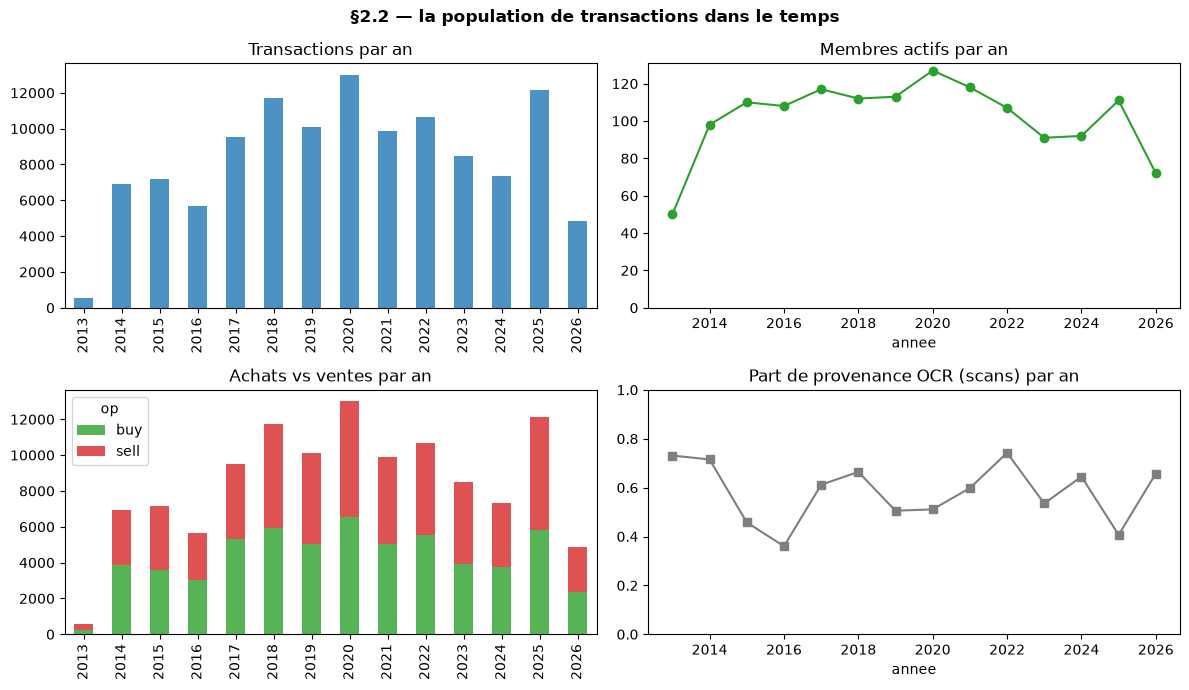

pic d'activité : 2020 (12993 trades) | achats 50.8% / ventes 49.2%


In [19]:
# trades/an, membres actifs/an, buy vs sell, part de provenance OCR (contrôle du creux de collecte)
dfx["annee"] = dfx["traded"].dt.year
_by = dfx.groupby("annee")
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
_by.size().plot(kind="bar", ax=ax[0,0], color="tab:blue", alpha=.8)
ax[0,0].set_title("Transactions par an"); ax[0,0].set_xlabel("")
_by["bioguide_id"].nunique().plot(kind="line", marker="o", ax=ax[0,1], color="tab:green")
ax[0,1].set_title("Membres actifs par an"); ax[0,1].set_ylim(0, None)
_bs = dfx.groupby(["annee","op"]).size().unstack(fill_value=0)
_bs.plot(kind="bar", stacked=True, ax=ax[1,0], color={"buy":"tab:green","sell":"tab:red"}, alpha=.8)
ax[1,0].set_title("Achats vs ventes par an"); ax[1,0].set_xlabel("")
_prov = dfx.assign(ocr=dfx.provenance.str.contains("ocr", case=False, na=False)).groupby("annee")["ocr"].mean()
_prov.plot(kind="line", marker="s", ax=ax[1,1], color="tab:gray")
ax[1,1].set_title("Part de provenance OCR (scans) par an"); ax[1,1].set_ylim(0,1)
fig.suptitle("§2.2 — la population de transactions dans le temps", fontweight="bold")
plt.tight_layout(); fig.savefig(FIG('P1_population_temps'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"pic d'activité : {_by.size().idxmax()} ({_by.size().max()} trades) | achats {(dfx.op=='buy').mean():.1%} / ventes {(dfx.op=='sell').mean():.1%}")

**A2 — Une poignée de membres fait l'essentiel.** *Les 2 plus actifs = 41 % des trades.* Conséquence : toute stat **par trade ≠ par membre**.

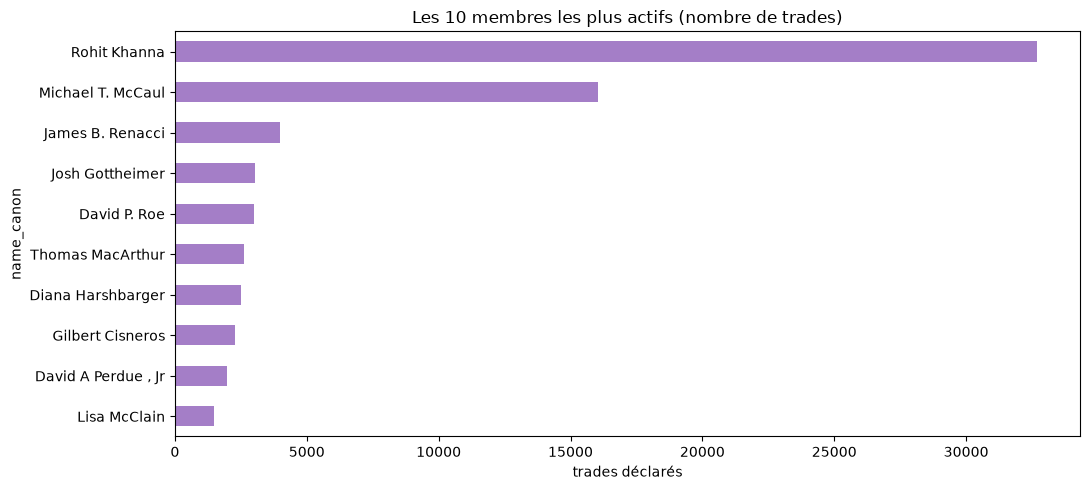

les 2 plus actifs (Khanna, McCaul) = 41% de tous les trades — une stat par trade est écrasée par eux


In [20]:
# A2 : les 10 membres les plus actifs (simple, sans Gini/Lorenz)
_top = dfx.groupby("name_canon").size().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(11, 5))
_top.iloc[::-1].plot(kind="barh", ax=ax, color="tab:purple", alpha=.85)
ax.set_title("Les 10 membres les plus actifs (nombre de trades)"); ax.set_xlabel("trades déclarés")
_share2 = _top.head(2).sum() / len(dfx)
plt.tight_layout(); fig.savefig(FIG('P2_top_membres'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"les 2 plus actifs (Khanna, McCaul) = {_share2:.0%} de tous les trades — une stat par trade est écrasée par eux")

**A3 — Souvent, c'est le conjoint qui passe l'ordre.** *Conjoint 37,9 % > élu 25,4 %.*

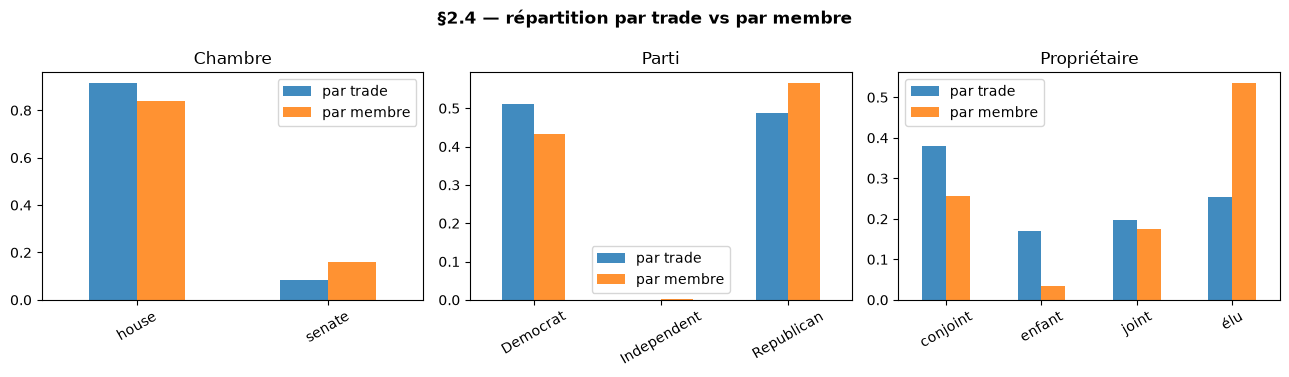

owner par trade : {'conjoint': 0.379, 'élu': 0.254, 'joint': 0.197, 'enfant': 0.17}


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, col, titre in [(ax[0],"chamber","Chambre"), (ax[1],"party","Parti"), (ax[2],"owner_n","Propriétaire")]:
    _vc_tr = dfx[col].value_counts(normalize=True)
    _vc_mb = dfx.groupby("bioguide_id")[col].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan).value_counts(normalize=True)
    _cmp = pd.DataFrame({"par trade": _vc_tr, "par membre": _vc_mb}).fillna(0)
    _cmp.plot(kind="bar", ax=a, color=["tab:blue","tab:orange"], alpha=.85)
    a.set_title(titre); a.set_xlabel(""); a.tick_params(axis="x", rotation=30)
fig.suptitle("§2.4 — répartition par trade vs par membre", fontweight="bold")
plt.tight_layout(); fig.savefig(FIG('P3_proprietaires'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print("owner par trade :", dfx.owner_n.value_counts(normalize=True).round(3).to_dict())

**A4 — Comment ils déclarent : par fourchettes, avec du délai.** *75 % à la 1ʳᵉ tranche (≈ 8 000 $) · délai médian 27 j · 11,7 % en retard.* Choix : montant = milieu de fourchette ; date = divulgation.

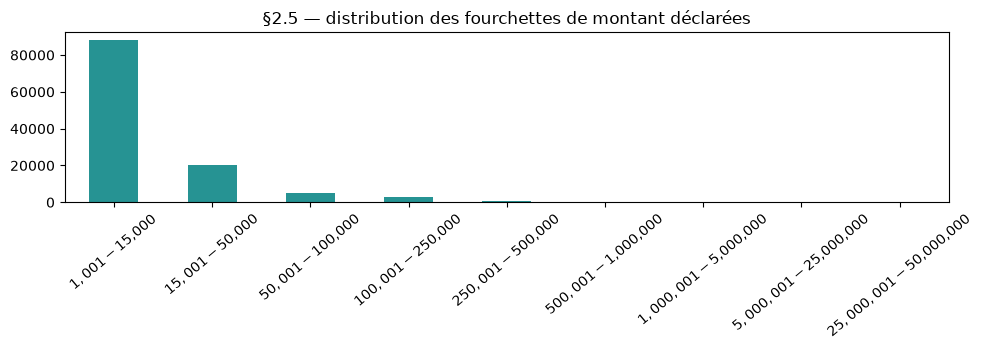

75% des trades sont à la 1re fourchette (midpoint 8 000,5 $).
⚠ le montant est une MESURE CENSURÉE PAR INTERVALLE : toute stat en $ (via midpoint) est une approximation ±facteur ~2.


In [22]:
# histogramme ordonné des fourchettes ; part de la 1re fourchette
_order = ["$1,001 - $15,000","$15,001 - $50,000","$50,001 - $100,000","$100,001 - $250,000",
          "$250,001 - $500,000","$500,001 - $1,000,000","$1,000,001 - $5,000,000",
          "$5,000,001 - $25,000,000","$25,000,001 - $50,000,000","$50,000,000 +"]
_ar = dfx["amount_range"].value_counts()
_ar = _ar.reindex([o for o in _order if o in _ar.index])
fig, ax = plt.subplots(figsize=(10, 3.6))
_ar.plot(kind="bar", ax=ax, color="teal", alpha=.85)
ax.set_title("§2.5 — distribution des fourchettes de montant déclarées"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=40); plt.tight_layout(); fig.savefig(FIG('P4a_fourchettes'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
_p1 = (dfx.size_usd <= 8000.5).mean()
print(f"{_p1:.0%} des trades sont à la 1re fourchette (midpoint 8 000,5 $).")
print("⚠ le montant est une MESURE CENSURÉE PAR INTERVALLE : toute stat en $ (via midpoint) est une approximation ±facteur ~2.")

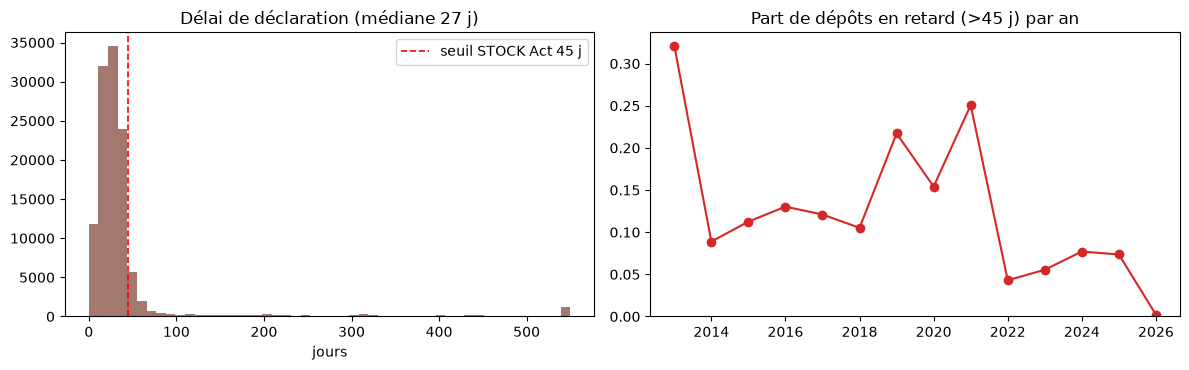

délai médian 27 j | p90 49 j | en retard (>45j) 11.7%


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
_lag = dfx["lag_days"].clip(lower=0)
ax[0].hist(_lag.clip(upper=_lag.quantile(.99)), bins=50, color="tab:brown", alpha=.8)
ax[0].axvline(45, color="red", ls="--", lw=1.2, label="seuil STOCK Act 45 j")
ax[0].set_title(f"Délai de déclaration (médiane {_lag.median():.0f} j)"); ax[0].set_xlabel("jours"); ax[0].legend()
_late = dfx.groupby("annee")["flag_late_filing"].mean()
_late.plot(kind="line", marker="o", ax=ax[1], color="tab:red")
ax[1].set_title("Part de dépôts en retard (>45 j) par an"); ax[1].set_ylim(0, None); ax[1].set_xlabel("")
plt.tight_layout(); fig.savefig(FIG('P4b_delai'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"délai médian {_lag.median():.0f} j | p90 {_lag.quantile(.9):.0f} j | en retard (>45j) {dfx.flag_late_filing.mean():.1%}")

**A4c — Achètent-ils dans les secteurs qu'ils régulent ? (conflit d'intérêt)** *Seulement ~16 % des achats tombent dans un secteur supervisé par leurs comités — faible en moyenne, mais quelques membres très alignés.*

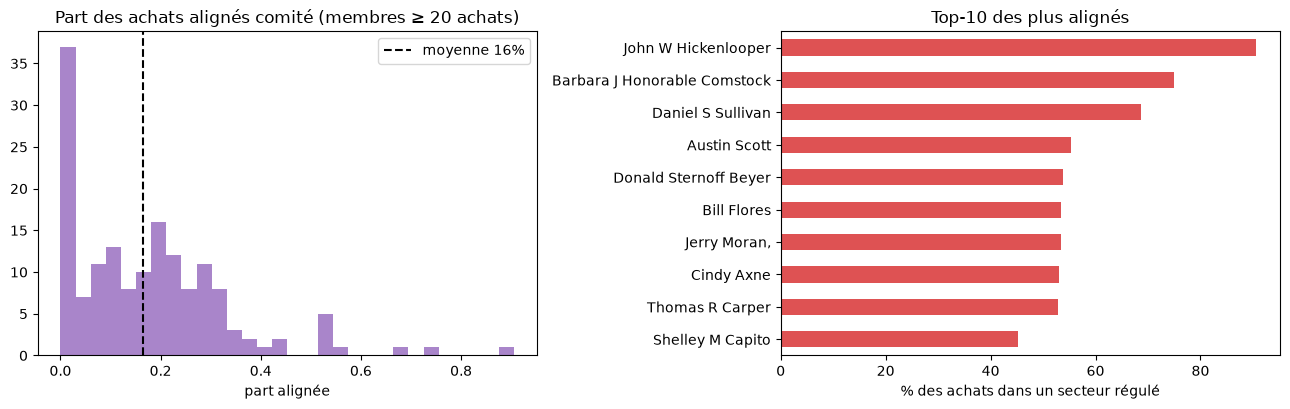

conflit : 16.4% des achats tombent dans un secteur régulé par les comités du membre (faible en agrégat)


In [24]:
# conflit d'intérêt : part des achats dont le SECTEUR est régulé par les comités du membre (logique nb09 §9)
import re
SECTEURS_REG = {   # code THOMAS du comité -> secteurs GICS supervisés (jurisdiction officielle)
    "HSAG": {"Consumer Staples", "Materials"},          "SSAF": {"Consumer Staples", "Materials"},
    "HSAS": {"Industrials"},  "SSAS": {"Industrials"},  "HLIG": {"Industrials"},
    "HSHM": {"Industrials", "Information Technology"},
    "HSBA": {"Financials", "Real Estate"},              "SSBK": {"Financials", "Real Estate"},
    "HSIF": {"Energy", "Utilities", "Health Care", "Communication Services"},
    "HSII": {"Energy", "Materials", "Utilities"},       "SSEG": {"Energy", "Utilities", "Materials"},
    "SSEV": {"Utilities", "Materials", "Industrials"},  "HSPW": {"Industrials", "Utilities"},
    "SSCM": {"Industrials", "Communication Services", "Information Technology"},
    "HSWM": {"Health Care", "Financials"},              "SSFI": {"Health Care", "Financials"},
    "HSSY": {"Information Technology"},                 "SSHR": {"Health Care"},  "HSVR": {"Health Care"},
}   # comités transverses (budget/justice/règlement) -> aucun secteur (sinon la notion perd son sens)
def _codes_racine(s):
    if not isinstance(s, str): return frozenset()
    return frozenset(t.strip()[:4] for t in s.split(";") if re.fullmatch(r"[A-Z]{4}\d*", t.strip()))
_codes = dfx["committee_membership"].map(_codes_racine)
_juri = _codes.map(lambda cs: frozenset().union(*[SECTEURS_REG.get(c, set()) for c in cs]) if cs else frozenset())
dfx["ci"] = [s in sm for s, sm in zip(dfx["sector_gics"], _juri)]
_pool = dfx.loc[dfx.op == "buy", "ci"].mean()
_al = dfx[dfx.op == "buy"].groupby("bioguide_id")["ci"].agg(n="size", part="mean"); _al = _al[_al.n >= 20]
_top = _al.sort_values("part", ascending=False).head(10).copy()
_nm = beh["name"].reindex(_top.index)
_top.index = [n if isinstance(n, str) else b for n, b in zip(_nm, _top.index)]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(_al.part, bins=30, color="tab:purple", alpha=.8)
ax[0].axvline(_pool, color="k", ls="--", label=f"moyenne {_pool:.0%}")
ax[0].set_title("Part des achats alignés comité (membres ≥ 20 achats)"); ax[0].set_xlabel("part alignée"); ax[0].legend()
(_top.part * 100).iloc[::-1].plot(kind="barh", ax=ax[1], color="tab:red", alpha=.8)
ax[1].set_title("Top-10 des plus alignés"); ax[1].set_xlabel("% des achats dans un secteur régulé")
plt.tight_layout(); fig.savefig(FIG('P4c_conflit'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"conflit : {_pool:.1%} des achats tombent dans un secteur régulé par les comités du membre (faible en agrégat)")

**A5 — Des portefeuilles concentrés : une grosse position domine.** *La plus grosse position pèse ~45 % du portefeuille en moyenne.* On le voit sur la composition dans le temps (exemple : Pelosi).

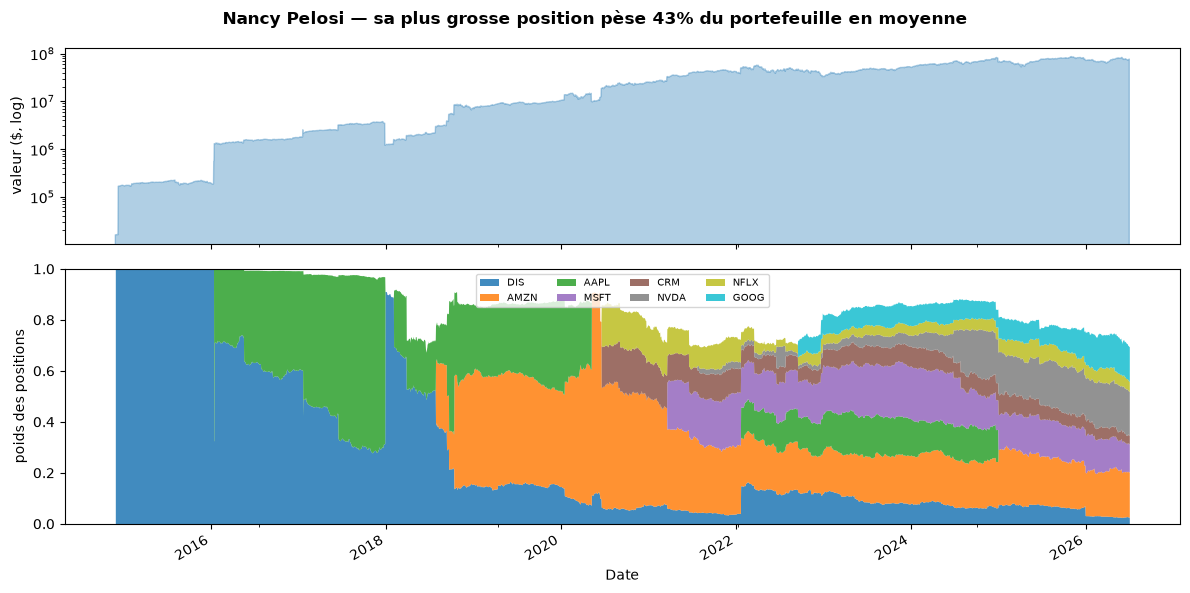

plus grosse position (moyenne, sur les 266) : 45%


In [25]:
# A5a : ce qu'il y a dedans — la composition dans le temps (exemple : Pelosi), sans HHI/N_eff
_bid = "P000197"
_g = df[df.bioguide_id == _bid]; _N = member_shares(_g)
_P = pd.DataFrame({tk: prices[tk] for tk in _N.columns}); _V = (_N*_P).sum(axis=1); _act = _V > 0
_W = (_N*_P).div(_V, axis=0)[_act]
_top8 = _W.mean().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1.3]})
ax[0].fill_between(_V[_act].index, _V[_act].values, color=C_M, alpha=.35); ax[0].set_yscale("log")
ax[0].set_ylabel("valeur ($, log)")
_W[_top8].plot.area(ax=ax[1], lw=0, alpha=.85, cmap="tab10")
ax[1].set_ylim(0, 1); ax[1].set_ylabel("poids des positions"); ax[1].legend(fontsize=7, ncol=4, loc="upper center")
_big = _W.max(axis=1).mean()
fig.suptitle(f"Nancy Pelosi — sa plus grosse position pèse {_big:.0%} du portefeuille en moyenne", fontweight="bold")
plt.tight_layout(); fig.savefig(FIG('P5_composition'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"plus grosse position (moyenne, sur les 266) : {beh.top1.mean():.0%}")

**A5b — Et ils gardent longtemps.** *Quand ils revendent, c'est après ~1 an ; 44 % des positions ne sont jamais revendues.*

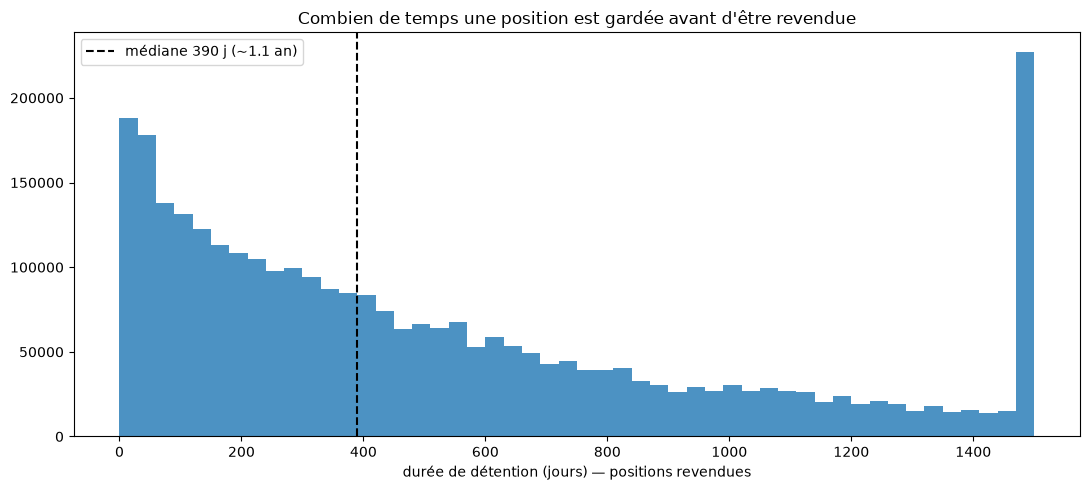

durée médiane revendues 390 j (~1.1 an) | 44% des positions jamais revendues


In [26]:
# A5b : combien de temps une position est gardée (durées des positions REVENDUES), sans Kaplan-Meier
_w = np.maximum(1, (closed.parts.values/closed.parts.min()).round().astype(int).clip(max=50))
_dur = np.repeat(closed.duree.values, _w); _med = np.median(_dur)
_pct_open = opened.parts.sum() / (closed.parts.sum() + opened.parts.sum())
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(np.clip(_dur, 0, 1500), bins=50, color=C_M, alpha=.8)
ax.axvline(_med, color="k", ls="--", label=f"médiane {_med:.0f} j (~{_med/365:.1f} an)")
ax.set_xlabel("durée de détention (jours) — positions revendues"); ax.legend()
ax.set_title("Combien de temps une position est gardée avant d'être revendue")
plt.tight_layout(); fig.savefig(FIG('P5b_duree'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"durée médiane revendues {_med:.0f} j (~{_med/365:.1f} an) | {_pct_open:.0%} des positions jamais revendues")

**A6 — Chacun a ses secteurs de prédilection.** *Dominante la plus fréquente : informatique.*

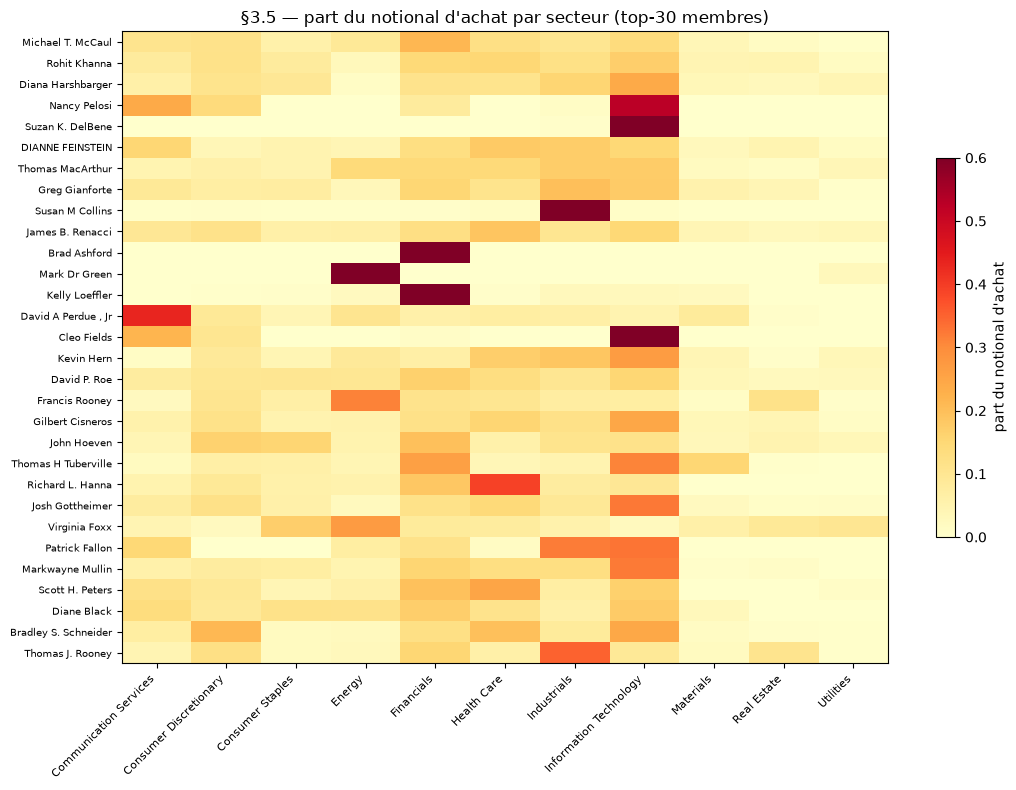

secteur dominant le plus fréquent : {'Information Technology': 82, 'Financials': 54, 'Consumer Discretionary': 28}


In [27]:
# part du notional d'ACHAT par secteur, top-30 membres par notional
_ach = dfx[dfx.op == "buy"]
_notional = _ach.groupby("bioguide_id")["size_usd"].sum().sort_values(ascending=False)
_top30 = _notional.head(30).index
# NB pandas 3.0 : groupby(...).apply(...) ré-injecte la clé de groupe dans l'index
# (index à 3 niveaux) -> reindex(_top30) ne s'aligne plus -> heatmap toute blanche.
# Normalisation robuste : chaque (membre,secteur) / total d'achat du membre.
_g = _ach[_ach.bioguide_id.isin(_top30)].groupby(["bioguide_id","sector_gics"])["size_usd"].sum()
_hm = _g.div(_g.groupby(level=0).transform("sum")).unstack(fill_value=0)
_hm = _hm.reindex(_top30)
_hm.index = beh.reindex(_top30)["name"].values
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(_hm.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.6)
ax.set_xticks(range(len(_hm.columns))); ax.set_xticklabels(_hm.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(_hm))); ax.set_yticklabels(_hm.index, fontsize=7)
ax.set_title("§3.5 — part du notional d'achat par secteur (top-30 membres)")
fig.colorbar(im, ax=ax, shrink=.6, label="part du notional d'achat")
plt.tight_layout(); fig.savefig(FIG('P6_secteurs'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print("secteur dominant le plus fréquent :", beh.sect_dom.value_counts().head(3).to_dict())

**A7 — Le Congrès bat-il le marché ? À peine plus que le hasard.** *34 % des éligibles battent le SPY · le meilleur membre est un outlier de queue (p ≈ 2 %).* → les stats individuelles sont surtout du **bruit**, d'où l'intérêt de regarder des personnes concrètes sans sur-interpréter.

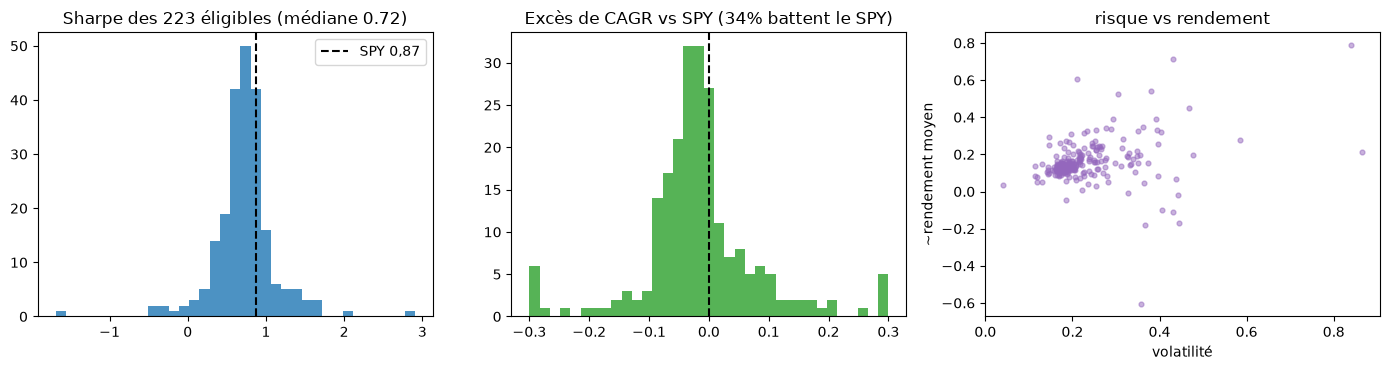

34% des éligibles battent le SPY sur LEUR fenêtre — à confronter au « 32 % » d'Unusual Whales (§6, année civile).


In [28]:
_e = beh[beh.eligible].copy()
# excès de CAGR vs SPY aligné sur la fenêtre de CHAQUE membre
def exces_spy(bid):
    r = wf_ret[bid]; nav = (1+r).cumprod(); cagr = nav.iloc[-1]**(252/len(r))-1
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod(); cagrs = navs.iloc[-1]**(252/len(rs))-1
    return cagr - cagrs
_e["exces_cagr"] = [exces_spy(b) for b in _e.index]
_pct_bat = (_e.exces_cagr > 0).mean()
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].hist(_e.sharpe, bins=35, color="tab:blue", alpha=.8); ax[0].axvline(0.87, color="k", ls="--", label="SPY 0,87")
ax[0].set_title(f"Sharpe des {len(_e)} éligibles (médiane {_e.sharpe.median():.2f})"); ax[0].legend()
ax[1].hist(_e.exces_cagr.clip(-.3,.3), bins=35, color="tab:green", alpha=.8); ax[1].axvline(0, color="k", ls="--")
ax[1].set_title(f"Excès de CAGR vs SPY ({_pct_bat:.0%} battent le SPY)")
ax[2].scatter(_e.vol, _e.sharpe*_e.vol, s=12, alpha=.5, color="tab:purple")
ax[2].set_xlabel("volatilité"); ax[2].set_ylabel("~rendement moyen"); ax[2].set_title("risque vs rendement")
plt.tight_layout(); fig.savefig(FIG('P7a_distributions'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"{_pct_bat:.0%} des éligibles battent le SPY sur LEUR fenêtre — à confronter au « 32 % » d'Unusual Whales (§6, année civile).")

TOP-15 par Sharpe :
                             name       party chamber  n_trades  n_eff  sharpe     t  exces_cagr                sect_dom
bioguide_id                                                                                                             
F000479            John Fetterman    Democrat  senate        10   2.09    2.90  3.08        0.55  Communication Services
B001319               Katie Britt  Republican  senate        24   8.28    2.02  2.23       -0.00  Information Technology
J000307                John James  Republican   house       257  51.52    1.72  2.78        0.03  Information Technology
M001220           Morgan McGarvey    Democrat   house        24   2.62    1.71  3.15        0.40  Information Technology
M001244              Ashley Moody  Republican  senate        23   4.58    1.66  1.99        0.68  Information Technology
W000821           Bruce Westerman  Republican   house       208  10.53    1.58  1.82        0.14              Financials
T000490     

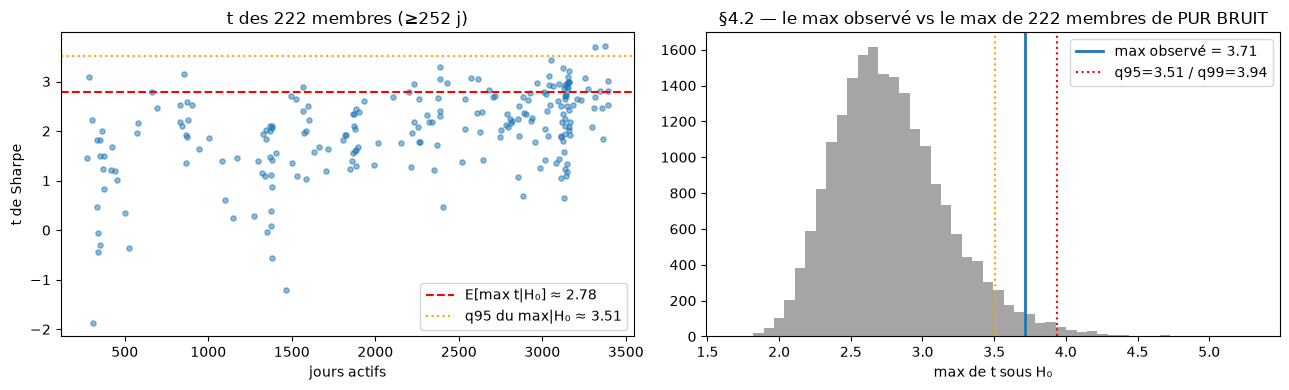

max t membre observé = 3.71 | sous H₀ (222 membres iid) : E[max]=2.78, q95=3.51, q99=3.94 → p(max≥3.71) ≈ 2.4%
→ le meilleur membre est un OUTLIER DE QUEUE (p≈2% sous H₀) : à peu près ce que le pur hasard produit sur ~222 membres, PAS une compétence démontrée.
  (05b §4.2 : ~20 membres « significatifs » à t>1,645 ≈ 11 attendus par hasard — même message au niveau du compte.)


In [29]:
# top/bottom-15 par Sharpe (>=252 j) ; t = Sharpe·√(T/252)
_ee = _e[_e.n_days >= 252].copy()
_ee["t"] = _ee.sharpe * np.sqrt(_ee.n_days/252)
_cols = ["name","party","chamber","n_trades","n_eff","sharpe","t","exces_cagr","sect_dom"]
print("TOP-15 par Sharpe :"); print(_ee.sort_values("sharpe", ascending=False).head(15)[_cols].round(2).to_string())
# distribution du MAX de t sous H0 par Monte-Carlo (N membres de PUR BRUIT)
_Nm = len(_ee); _rng42 = np.random.default_rng(42)
_maxnull = _rng42.standard_normal((20000, _Nm)).max(axis=1)
_E, _q95, _q99 = _maxnull.mean(), np.quantile(_maxnull, .95), np.quantile(_maxnull, .99)
_tmax = _ee.t.max(); _p = (_maxnull >= _tmax).mean()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(_ee.n_days, _ee.t, s=14, alpha=.5, color="tab:blue")
ax[0].axhline(_E, color="red", ls="--", label=f"E[max t|H₀] ≈ {_E:.2f}")
ax[0].axhline(_q95, color="orange", ls=":", label=f"q95 du max|H₀ ≈ {_q95:.2f}")
ax[0].set_xlabel("jours actifs"); ax[0].set_ylabel("t de Sharpe"); ax[0].set_title(f"t des {_Nm} membres (≥252 j)"); ax[0].legend()
ax[1].hist(_maxnull, bins=50, color="tab:gray", alpha=.7)
ax[1].axvline(_tmax, color="tab:blue", lw=2, label=f"max observé = {_tmax:.2f}")
ax[1].axvline(_q95, color="orange", ls=":"); ax[1].axvline(_q99, color="red", ls=":", label=f"q95={_q95:.2f} / q99={_q99:.2f}")
ax[1].set_xlabel("max de t sous H₀"); ax[1].set_title(f"§4.2 — le max observé vs le max de {_Nm} membres de PUR BRUIT"); ax[1].legend()
plt.tight_layout(); fig.savefig(FIG('P7b_maxt'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()
print(f"max t membre observé = {_tmax:.2f} | sous H₀ ({_Nm} membres iid) : E[max]={_E:.2f}, q95={_q95:.2f}, q99={_q99:.2f} → p(max≥{_tmax:.2f}) ≈ {_p:.1%}")
print(f"→ le meilleur membre est un OUTLIER DE QUEUE (p≈{_p:.0%} sous H₀) : à peu près ce que le pur hasard produit sur ~{_Nm} membres, PAS une compétence démontrée.")
print("  (05b §4.2 : ~20 membres « significatifs » à t>1,645 ≈ 11 attendus par hasard — même message au niveau du compte.)")

**T1 — Le Congrès en un tableau.**

In [30]:
# T1 : la population en une ligne de KPIs
from IPython.display import display
_el = beh[beh.eligible]
T1 = pd.Series({
    "membres (reconstruits)": len(beh),
    "membres jugeables (éligibles)": int(beh.eligible.sum()),
    "trades exploitables": len(df),
    "part des 2 plus actifs": f"{dfx.groupby('bioguide_id').size().sort_values().tail(2).sum()/len(dfx):.0%}",
    "part conjoint (trades)": f"{(dfx.owner_n=='conjoint').mean():.1%}",
    "délai médian de déclaration": f"{dfx.lag_days.median():.0f} j",
    "plus grosse position (moyenne)": f"{beh.top1.mean():.0%}",
    "part des positions jamais revendues": f"{opened.parts.sum()/(closed.parts.sum()+opened.parts.sum()):.0%}",
    "% éligibles battant le SPY": f"{(_el.exces_cagr_spy>0).mean():.0%}",
    "Sharpe médian éligibles / SPY": f"{_el.sharpe.median():.2f} / 0,83",
}).to_frame("valeur")
print("T1 — Le Congrès en un tableau", T1.shape)
display(T1)

T1 — Le Congrès en un tableau (10, 1)


,valeur
membres (reconstruits),266
membres jugeables (éligibles),223
trades exploitables,118029
part des 2 plus actifs,41%
part conjoint (trades),37.9%
délai médian de déclaration,27 j
plus grosse position (moyenne),45%
part des positions jamais revendues,44%
% éligibles battant le SPY,34%
Sharpe médian éligibles / SPY,"0.72 / 0,83"


# Partie B — Portraits : des stats sur des gens intéressants

*« Concrètement, à quoi ressemblent des membres réels, et que valent leurs chiffres ? »*

Pour chaque membre : **la fiche 4 panneaux** (NAV vs SPY · trades · poids top-8 · excès annuel) **et la carte
risque & perf** (100 $ investis vs SPY + drawdown, avec le verdict de significativité).

In [31]:
def fiche_membre(bid, zoom=None, save=None):
    g = df[df.bioguide_id == bid].sort_values("traded")
    gx = dfx[dfx.bioguide_id == bid]
    nom = beh.loc[bid, "name"] if bid in beh.index else bid
    r = wf_ret[bid]; nav = 100*(1+r).cumprod()
    rs = r_spy.reindex(r.index).fillna(0.0); navs = 100*(1+rs).cumprod()
    N = member_shares(g); P = pd.DataFrame({tk: prices[tk] for tk in N.columns}); V=(N*P).sum(axis=1); act=V>0
    W = (N*P).div(V, axis=0)[act]
    top8 = W.mean().sort_values(ascending=False).head(8).index
    fig, ax = plt.subplots(2, 2, figsize=(13, 7))
    ax[0,0].plot(nav.index, nav.values, color="tab:blue", label=nom)
    ax[0,0].plot(navs.index, navs.values, color="k", lw=1.2, label="SPY")
    ax[0,0].set_yscale("log"); ax[0,0].set_title(f"(A) NAV actions base 100 vs SPY"); ax[0,0].legend()
    for op, c in [("buy","tab:green"),("sell","tab:red")]:
        s = gx[gx.op==op]; ax[0,1].scatter(s.traded, s.size_usd, s=14, c=c, alpha=.5, label=op)
    ax[0,1].set_yscale("log"); ax[0,1].set_title("(B) timeline des trades (taille $, log)"); ax[0,1].legend()
    if len(top8):
        W[top8].plot.area(ax=ax[1,0], lw=0, alpha=.8, cmap="tab10")
        ax[1,0].set_title("(C) poids des 8 principales positions"); ax[1,0].legend(fontsize=6, ncol=2); ax[1,0].set_ylim(0,1)
    _ye = pd.Series({y: ((1+r[r.index.year==y]).prod()-1) - ((1+rs[rs.index.year==y]).prod()-1)
                     for y in sorted(set(r.index.year))})
    ax[1,1].bar(_ye.index, 100*_ye.values, color=["tab:green" if v>0 else "tab:red" for v in _ye.values], alpha=.8)
    ax[1,1].axhline(0, color="k", lw=.8); ax[1,1].set_title("(D) excès annuel vs SPY (%)")
    if zoom:
        for a in [ax[0,0], ax[0,1]]: a.set_xlim(pd.Timestamp(zoom[0]), pd.Timestamp(zoom[1]))
    fig.suptitle(f"{nom} — {len(g)} trades | Sharpe {stats(r)['sharpe']:.2f} | "
                 f"conjoint {beh.loc[bid,'conjoint_share']:.0%} | lag méd {beh.loc[bid,'lag_med']:.0f} j", fontweight="bold")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
print("helper fiche_membre prêt.")

helper fiche_membre prêt.


In [32]:
# carte risque & perf : 100 $ investis vs SPY + drawdown + verdict de significativité
def carte_perf(bid, save=None):
    r = wf_ret[bid]; nav = (1+r).cumprod()*100
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod()*100
    row = beh.loc[bid]; nom = row["name"]
    fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    ax[0].plot(nav.index, nav.values, color=C_M, lw=1.4, label=nom)
    ax[0].plot(navs.index, navs.values, color=C_SPY, lw=1.2, label="SPY (même fenêtre)")
    ax[0].set_yscale("log"); ax[0].legend()
    ax[0].set_title(f"100 $ investis | vol {row['vol']:.0%} · Sharpe {row['sharpe']:.2f} · "
                    f"maxDD {row['maxdd']:.0%} | β {row['beta']:.2f} · α {row['alpha_ann']:+.1%}/an (t {row['t_appr']:.2f})")
    ax[1].fill_between(nav.index, (nav/nav.cummax()-1).values, color=C_SELL, alpha=.5); ax[1].set_ylabel("drawdown")
    fig.suptitle(f"{nom} — {row['exces_cagr_spy']:+.1%}/an vs SPY, mais α (t {row['t_appr']:.2f}) et "
                 f"IR (t {row['t_ir']:.2f}) sous le seuil 2 : indiscernable de la chance",
                 fontweight="bold", fontsize=10)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
print("helper carte_perf prêt.")

helper carte_perf prêt.


**Le casting — 6 médiatisés + champions data (extrêmes chiffrés, choisis au runtime).**

In [33]:
# 6 médiatisés + champions data (sélection sur beh, dédoublonnée)
MEDIA = [("P000197","médiatisé : Pelosi"), ("K000389","médiatisé : Khanna"),
         ("M001157","médiatisé : McCaul"), ("G000583","médiatisé : Gottheimer"),
         ("T000278","médiatisé : Tuberville"), ("B001135","médiatisé : Burr (zoom COVID)")]
_media_ids = [b for b,_ in MEDIA]
_el = beh[beh.eligible]; _tk = beh[beh.n_trades_evalues.fillna(0) >= 50]
_notional = dfx.groupby("bioguide_id")["size_usd"].sum()
_champ = [
    (_el.sharpe.idxmax(), "champion : meilleur Sharpe"),
    (_notional.drop(index=[m for m in _media_ids if m in _notional.index]).idxmax(), "champion : plus gros notional"),
    (_tk.t_exces_trade.idxmax(), "champion : meilleur track/trade"),
    (_tk.t_exces_trade.idxmin(), "champion : pire track/trade"),
]
CASTING, _seen = list(MEDIA), set(_media_ids)
for bid, lbl in _champ:
    if bid not in _seen: CASTING.append((bid, lbl)); _seen.add(bid)
print("CASTING :")
for bid, lbl in CASTING:
    print(f"  {bid}  {beh.loc[bid,'name']:22s} — {lbl}  (Sharpe {beh.loc[bid,'sharpe']:.2f}, "
          f"n_trades {int(beh.loc[bid,'n_trades'])})")

CASTING :
  P000197  Nancy Pelosi           — médiatisé : Pelosi  (Sharpe 0.77, n_trades 135)
  K000389  Rohit Khanna           — médiatisé : Khanna  (Sharpe 0.87, n_trades 32684)
  M001157  Michael T. McCaul      — médiatisé : McCaul  (Sharpe 0.61, n_trades 16028)
  G000583  Josh Gottheimer        — médiatisé : Gottheimer  (Sharpe 0.78, n_trades 3054)
  T000278  Thomas H Tuberville    — médiatisé : Tuberville  (Sharpe 0.48, n_trades 738)
  B001135  RICHARD M BURR         — médiatisé : Burr (zoom COVID)  (Sharpe 0.53, n_trades 338)
  F000479  John Fetterman         — champion : meilleur Sharpe  (Sharpe 2.90, n_trades 10)
  H001086  Diana Harshbarger      — champion : plus gros notional  (Sharpe 0.90, n_trades 2519)
  W000779  Ron L Wyden            — champion : meilleur track/trade  (Sharpe 1.16, n_trades 231)
  T000475  David A. Trott         — champion : pire track/trade  (Sharpe 0.32, n_trades 232)


### Les portraits


=== Nancy Pelosi — médiatisé : Pelosi ===


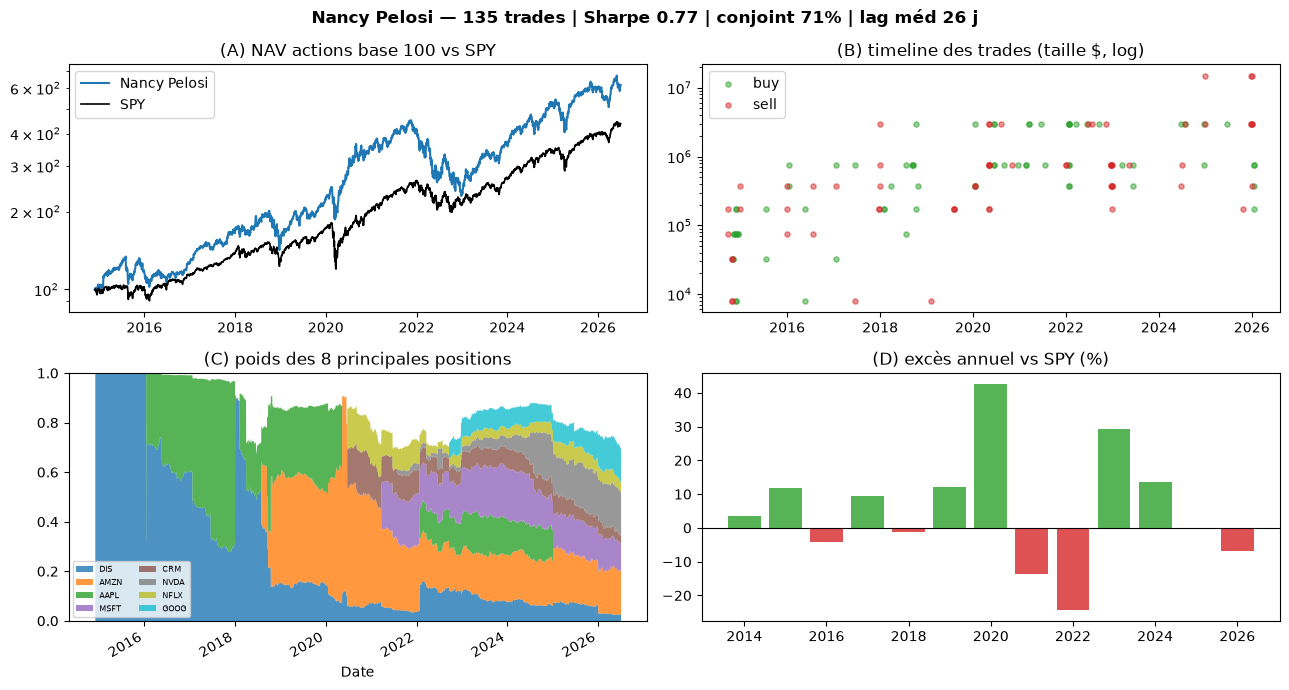

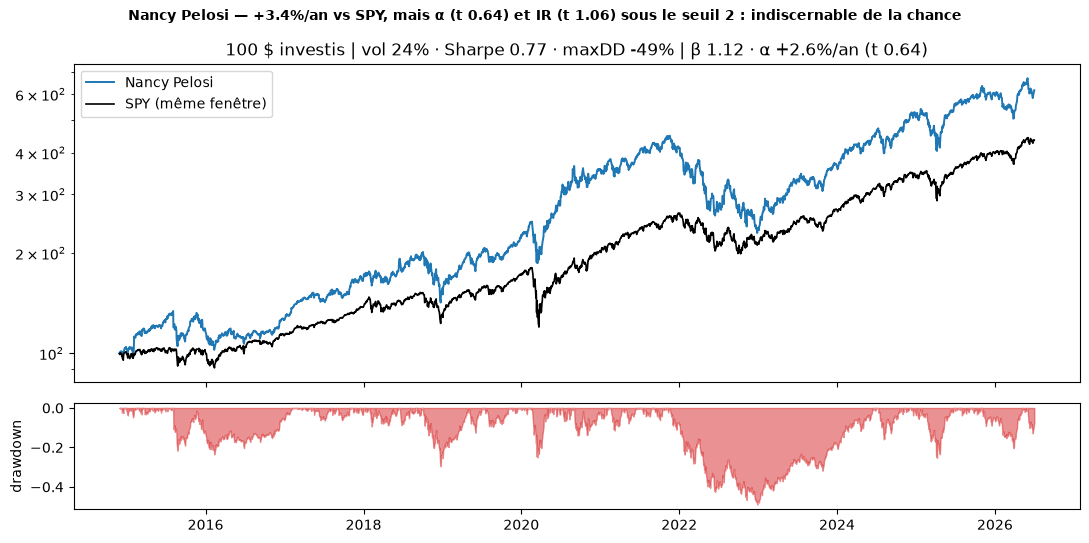


=== Rohit Khanna — médiatisé : Khanna ===


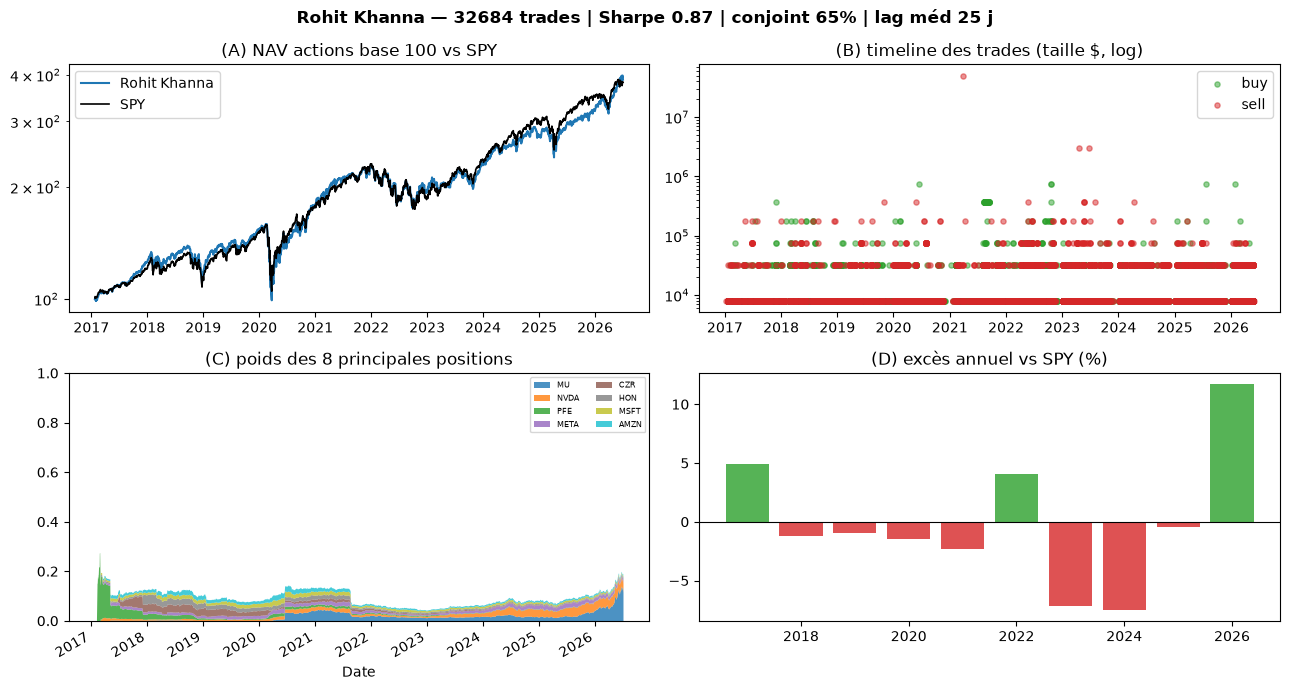

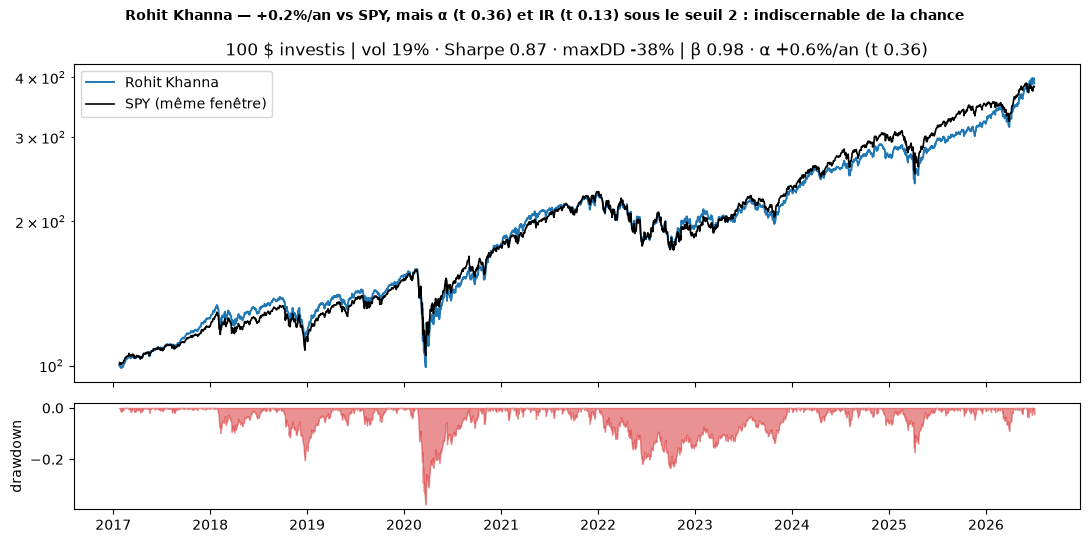


=== Michael T. McCaul — médiatisé : McCaul ===


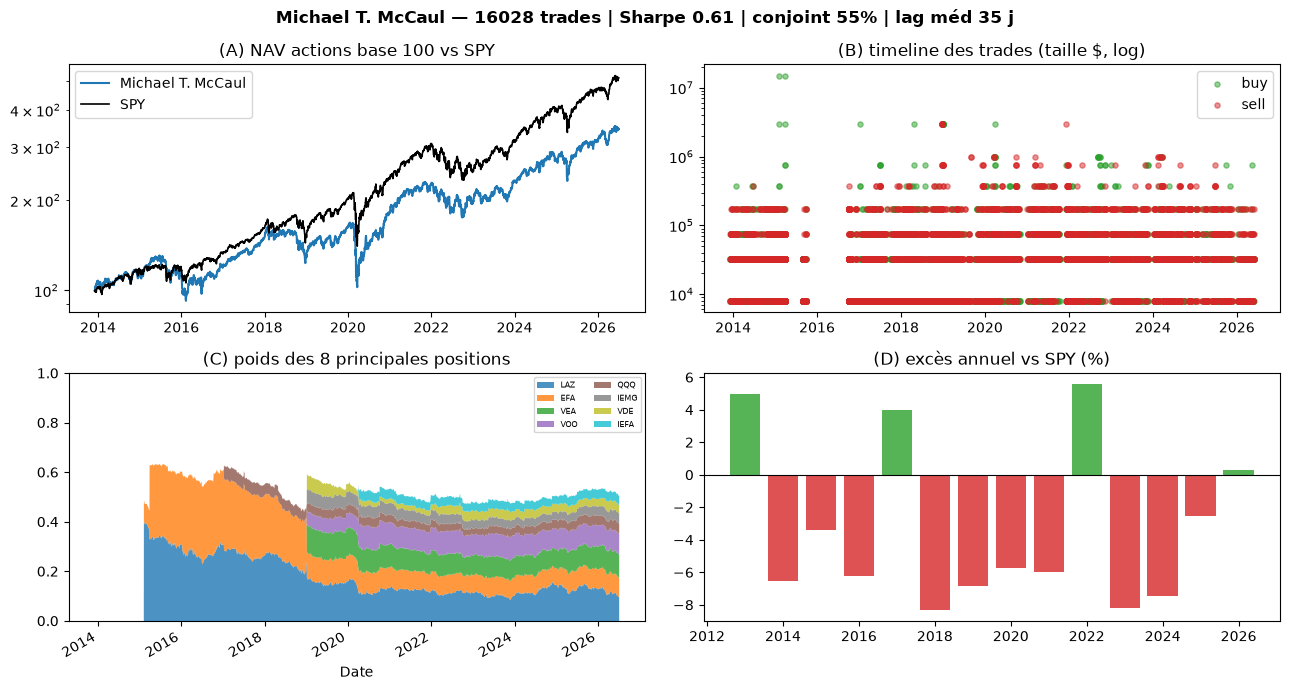

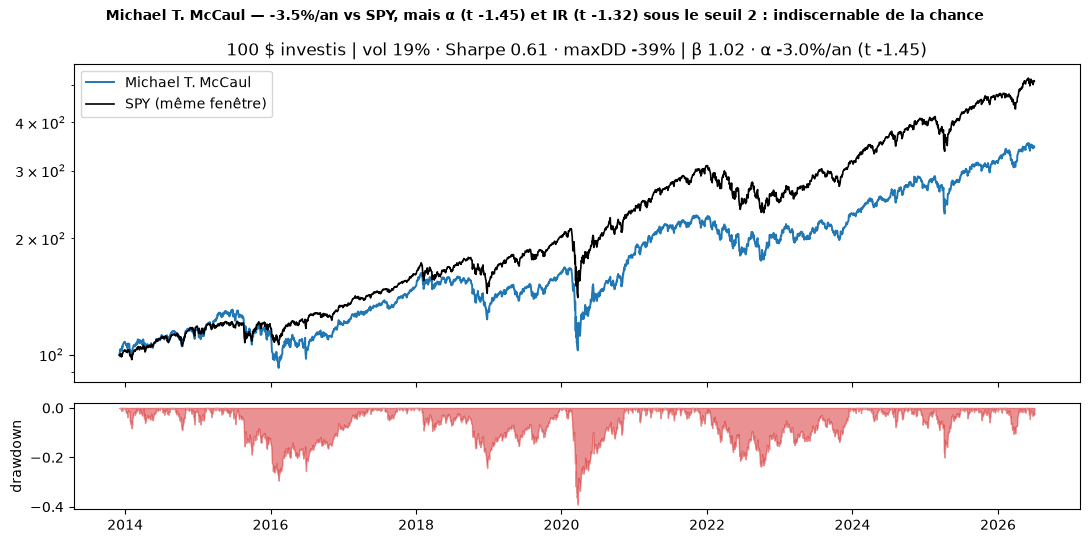


=== Josh Gottheimer — médiatisé : Gottheimer ===


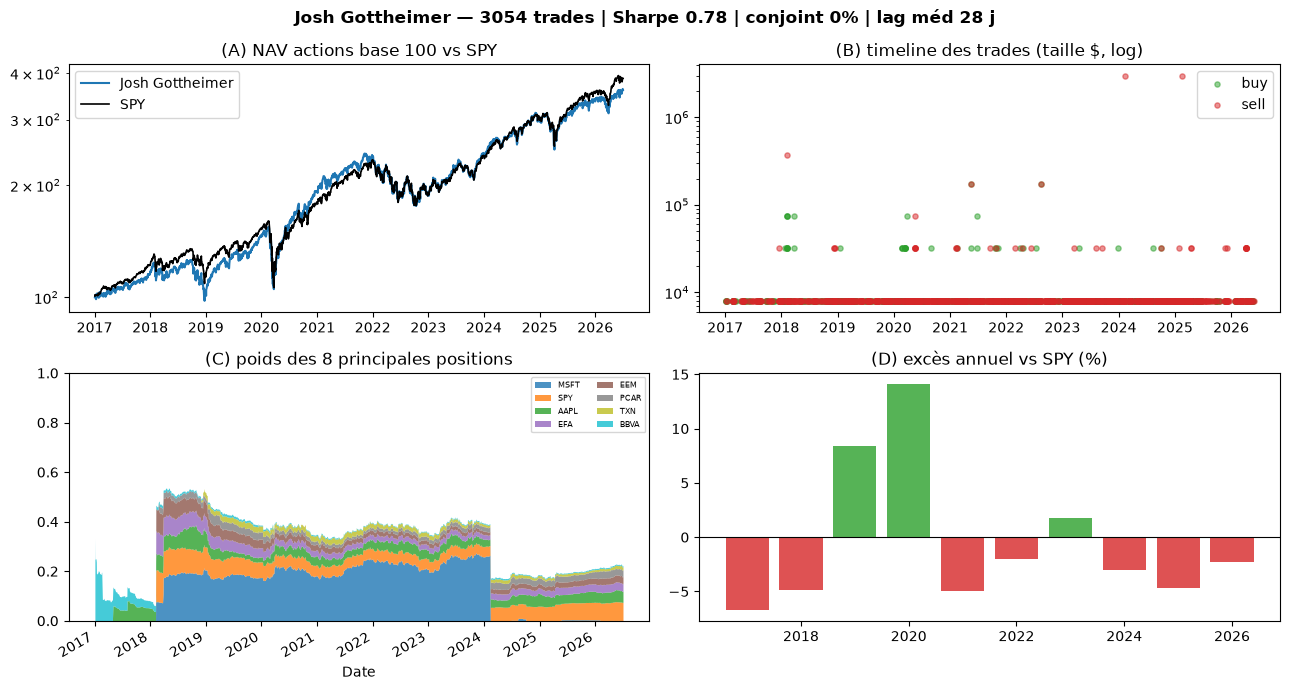

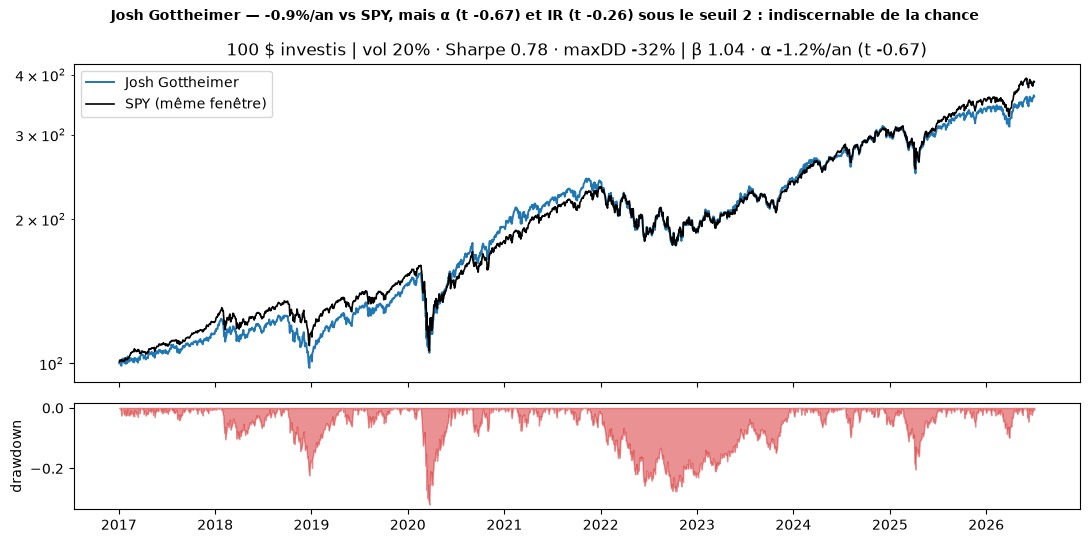


=== Thomas H Tuberville — médiatisé : Tuberville ===


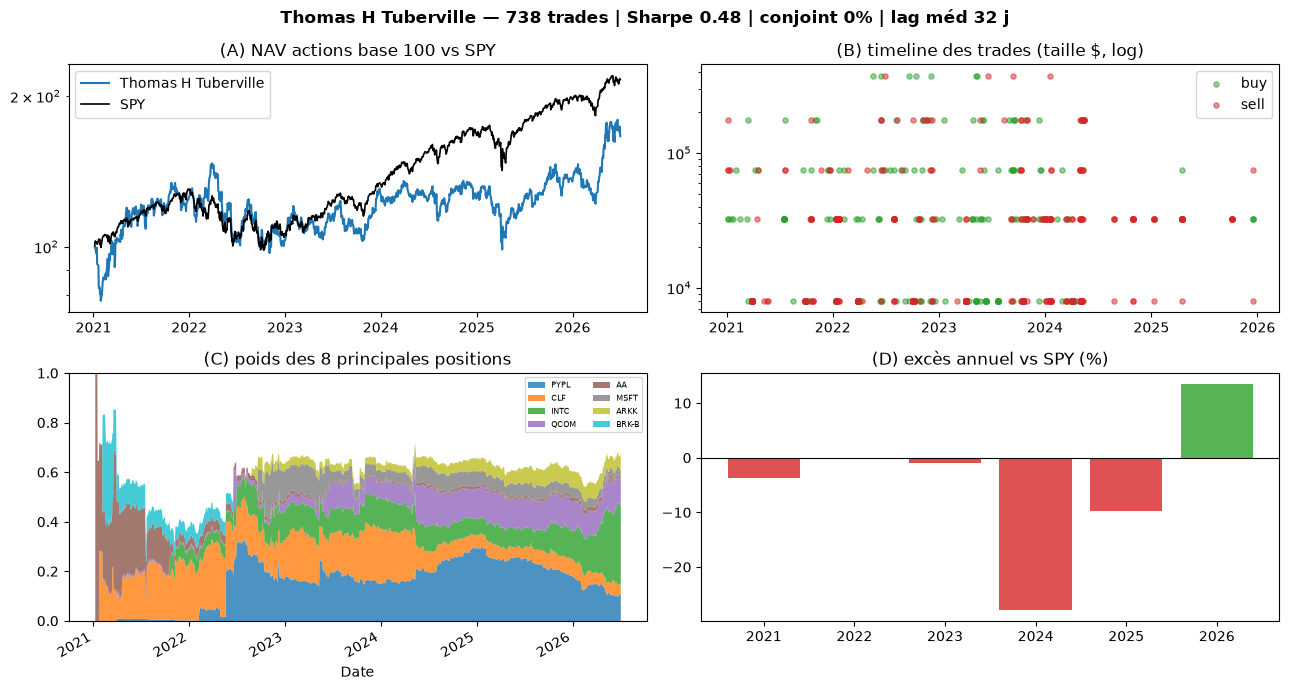

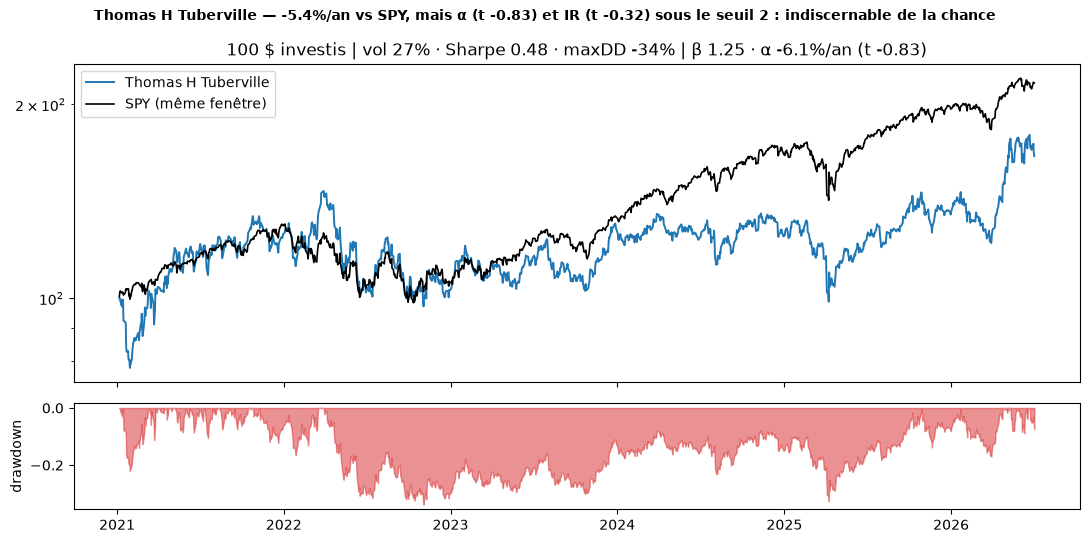


=== RICHARD M BURR — médiatisé : Burr (zoom COVID) ===


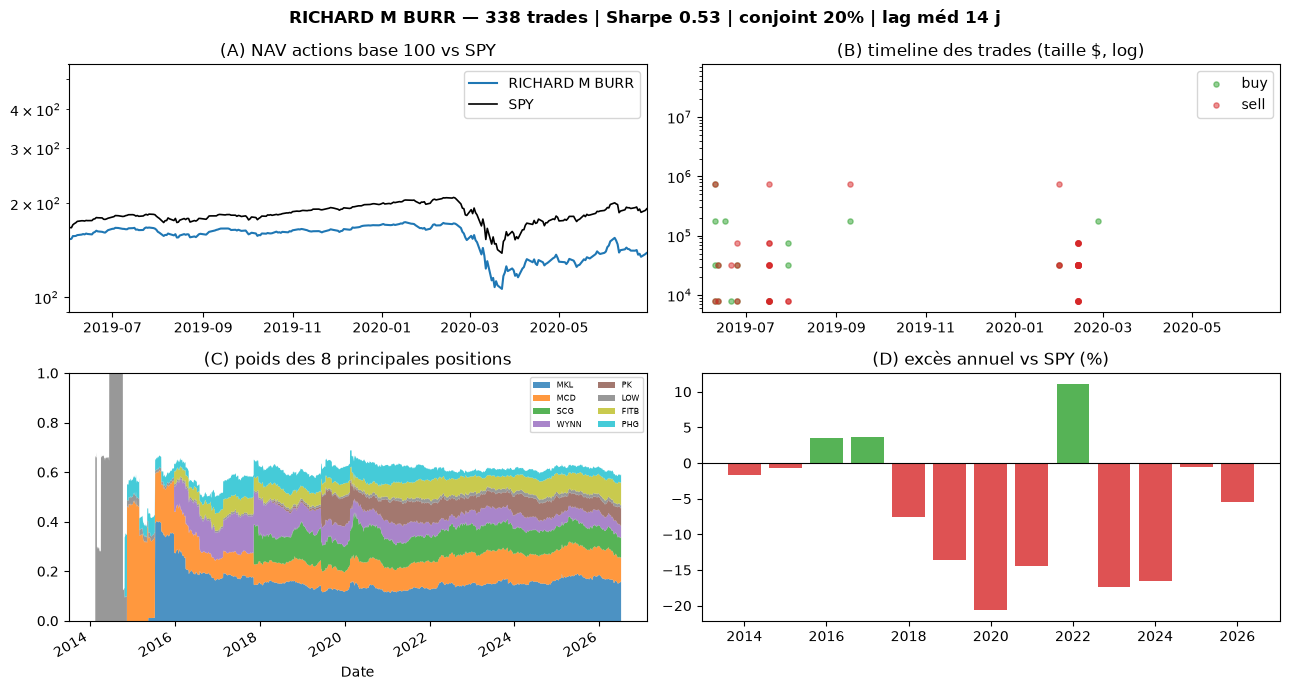

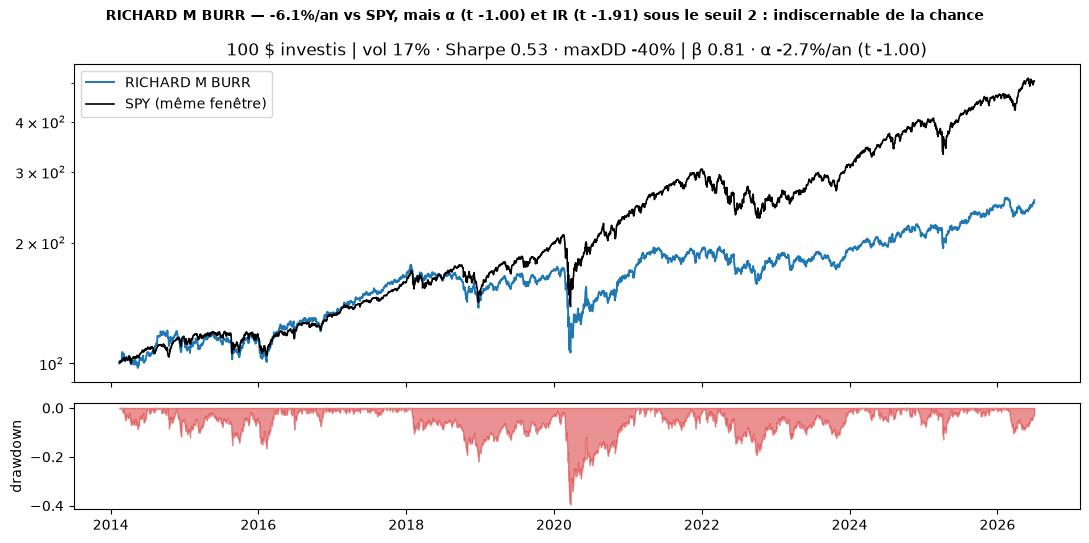


=== John Fetterman — champion : meilleur Sharpe ===


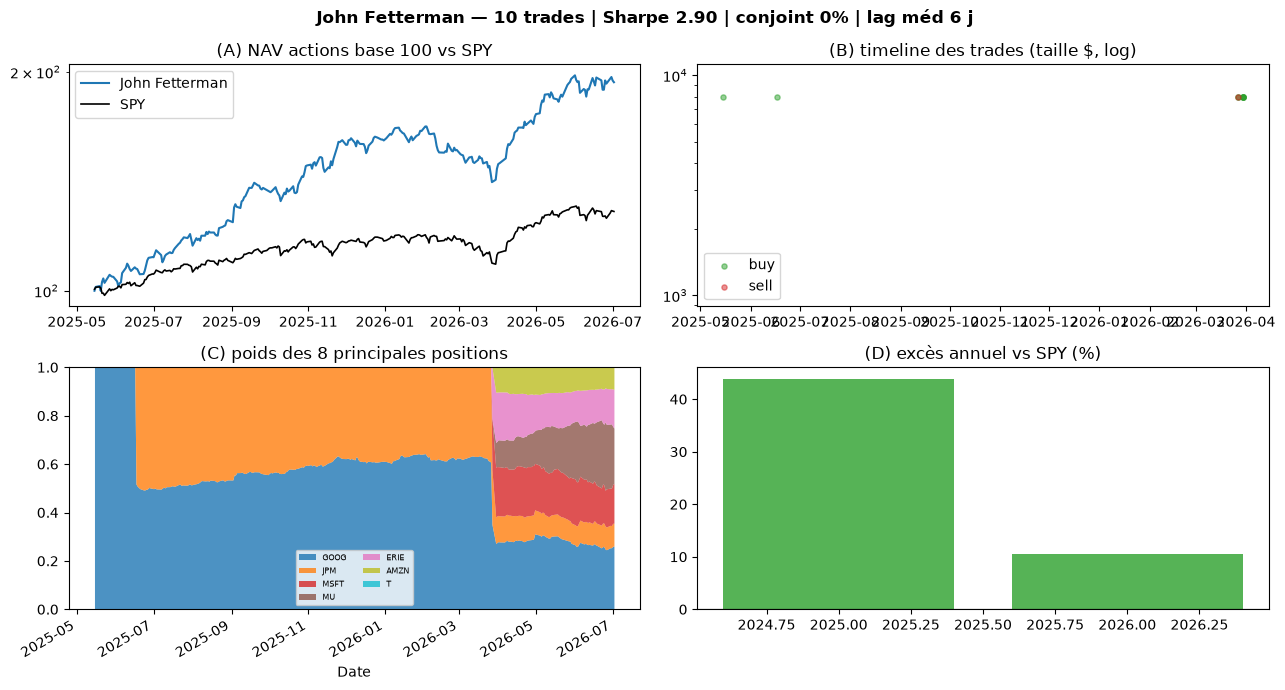

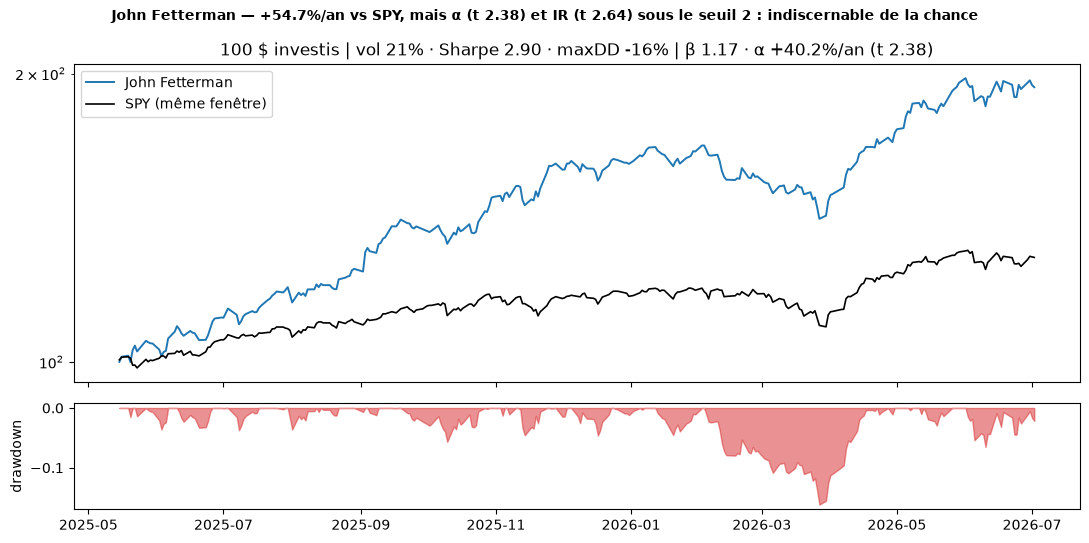


=== Diana Harshbarger — champion : plus gros notional ===


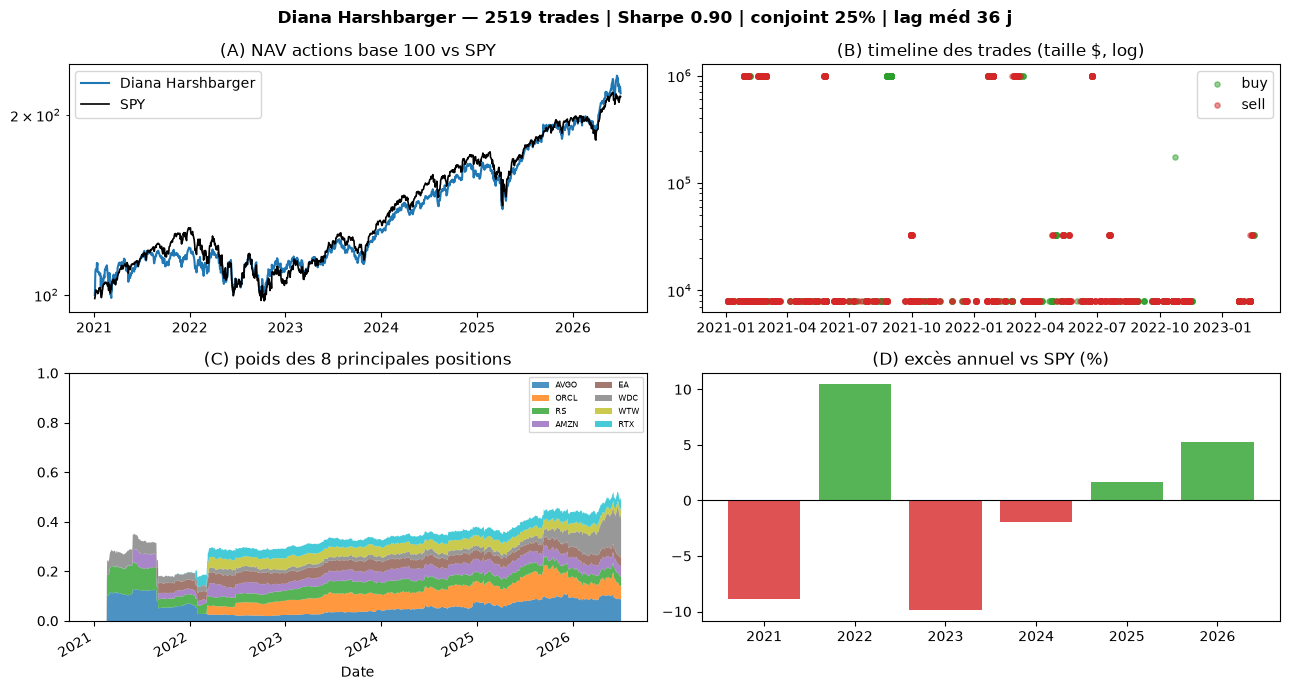

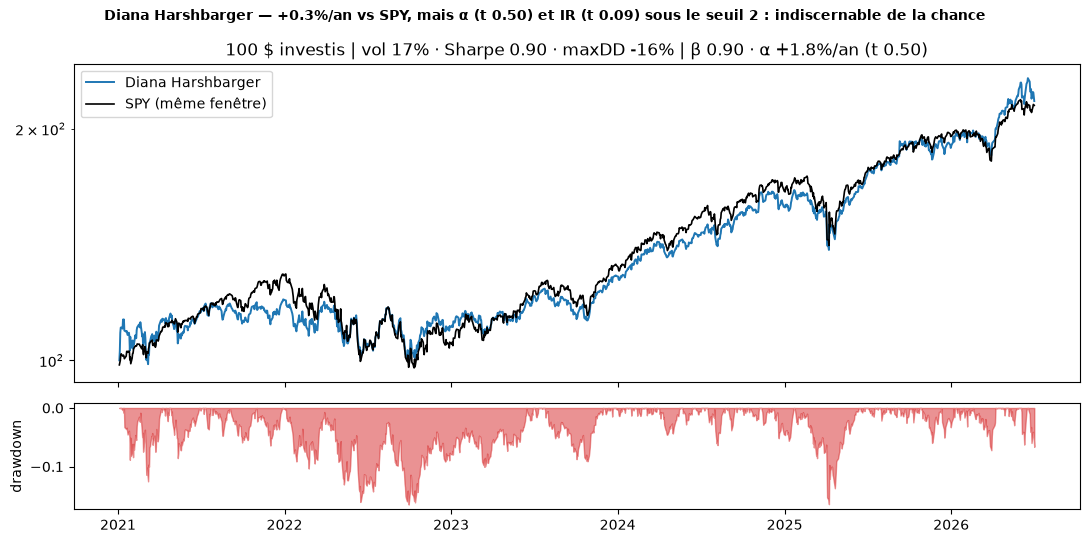


=== Ron L Wyden — champion : meilleur track/trade ===


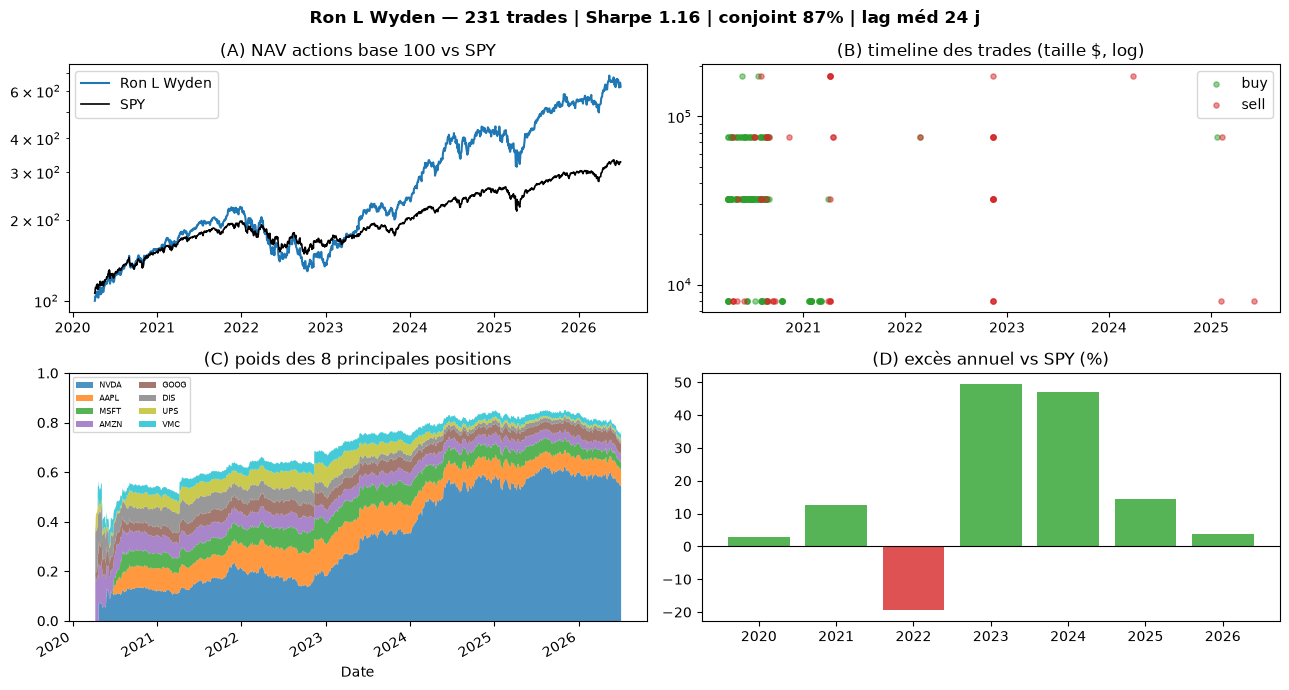

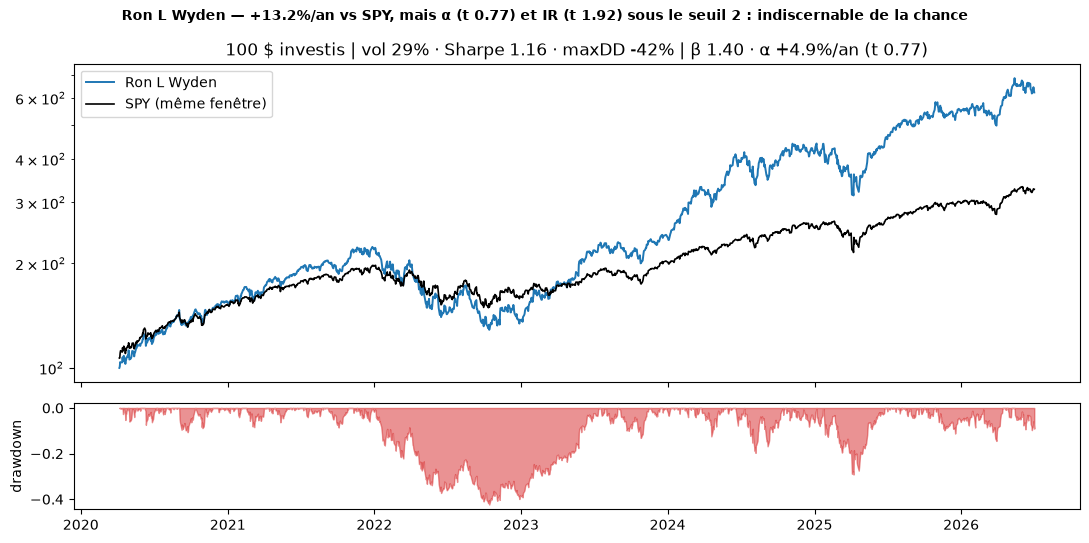


=== David A. Trott — champion : pire track/trade ===


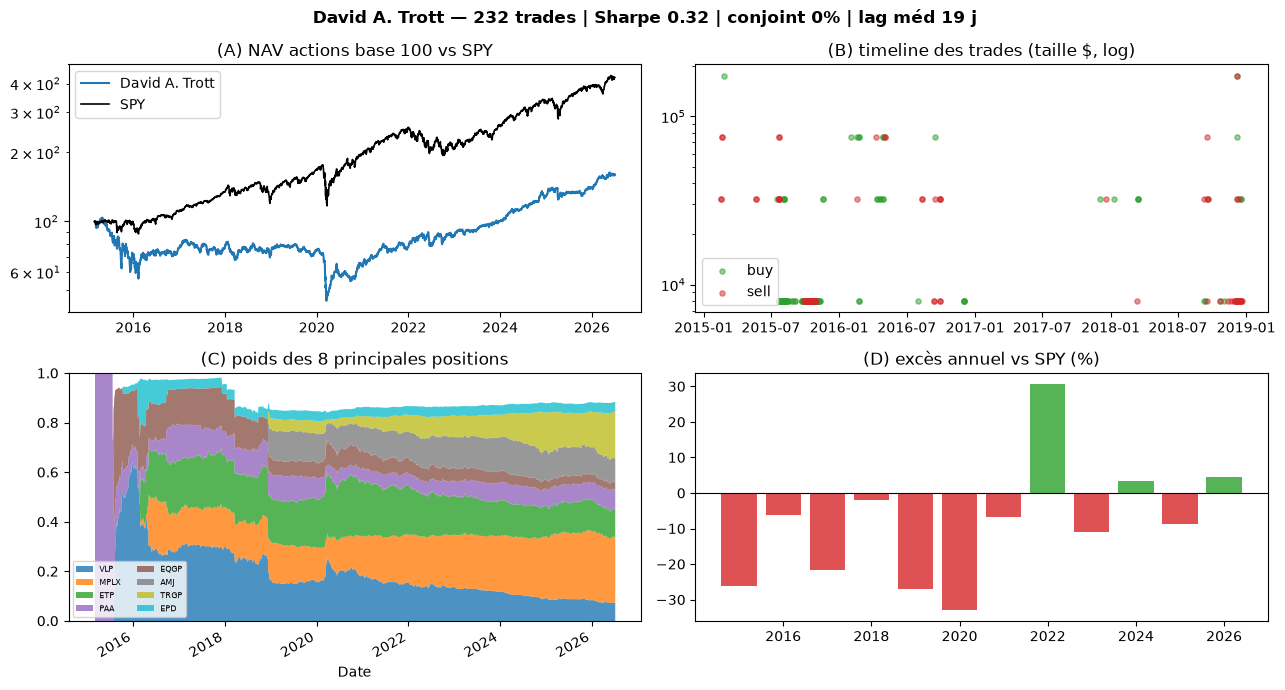

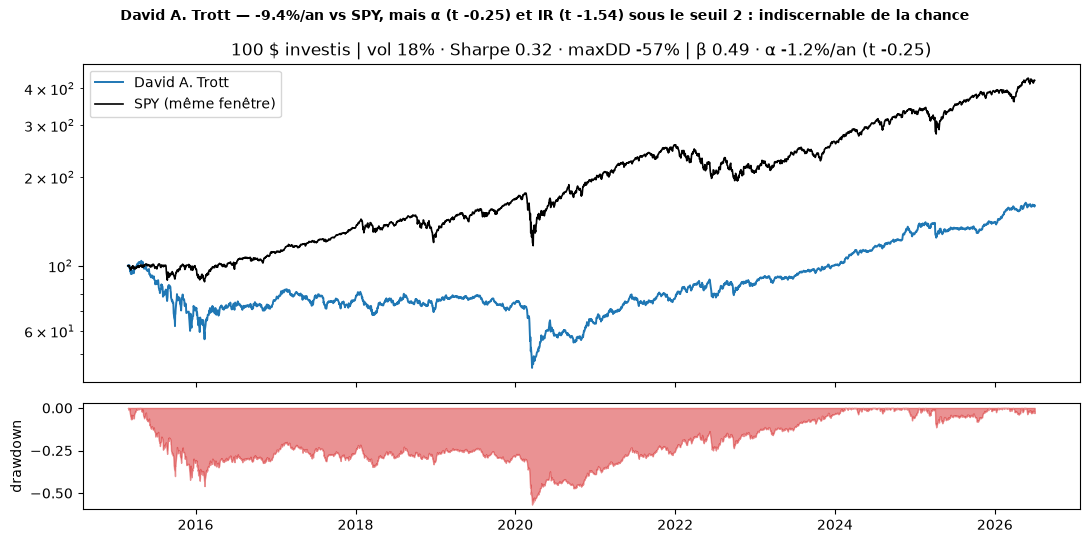

In [34]:
# fiche + carte pour chaque membre du casting (PNG dans figs_pop/)
for bid, lbl in CASTING:
    zoom = ("2019-06-01","2020-06-30") if bid == "B001135" else None
    print(f"\n=== {beh.loc[bid,'name']} — {lbl} ===")
    fiche_membre(bid, zoom=zoom, save=FIG(f"G_{bid}_fiche"))
    carte_perf(bid, save=FIG(f"G_{bid}_card"))

**T2 — La galerie en chiffres** (le tableau « stats sur des gens »).

In [35]:
# T2 : une ligne par portrait, les stats côte à côte
_cols = ["name","party","chamber","n_trades","sharpe","maxdd","beta","alpha_ann","t_appr",
         "ir","t_ir","hit_rate","profit_factor","conjoint_share","sect_dom","exces_cagr_spy"]
T2 = beh.loc[[b for b,_ in CASTING], _cols].copy()
T2.insert(0, "role", [lbl for _,lbl in CASTING])
for c in ["alpha_ann","hit_rate","conjoint_share","exces_cagr_spy","maxdd"]:
    T2[c] = (T2[c]*100).round(1)
print("T2 — la galerie en chiffres (α/hit/conjoint/excès/maxDD en %)", T2.shape)
display(T2.round(2))

T2 — la galerie en chiffres (α/hit/conjoint/excès/maxDD en %) (10, 17)


,role,name,party,chamber,n_trades,sharpe,maxdd,beta,alpha_ann,t_appr,ir,t_ir,hit_rate,profit_factor,conjoint_share,sect_dom,exces_cagr_spy
bioguide_id,,,,,,,,,,,,,,,,,
P000197,médiatisé : Pelosi,Nancy Pelosi,Democrat,house,135,0.77,-49.0,1.12,2.6,0.64,0.31,1.06,63.3,2.39,71.1,Information Technology,3.4
K000389,médiatisé : Khanna,Rohit Khanna,Democrat,house,32684,0.87,-37.6,0.98,0.6,0.36,0.04,0.13,40.2,0.88,65.2,Information Technology,0.2
M001157,médiatisé : McCaul,Michael T. McCaul,Republican,house,16028,0.61,-39.1,1.02,-3.0,-1.45,-0.37,-1.32,46.5,1.06,54.9,Financials,-3.5
G000583,médiatisé : Gottheimer,Josh Gottheimer,Democrat,house,3054,0.78,-31.9,1.04,-1.2,-0.67,-0.08,-0.26,43.3,1.00,0.0,Information Technology,-0.9
T000278,médiatisé : Tuberville,Thomas H Tuberville,Republican,senate,738,0.48,-33.8,1.25,-6.1,-0.83,-0.14,-0.32,42.8,1.06,0.0,Information Technology,-5.4
B001135,médiatisé : Burr (zoom COVID),RICHARD M BURR,Republican,senate,338,0.53,-39.5,0.81,-2.7,-1.00,-0.54,-1.91,45.9,0.70,20.1,Financials,-6.1
F000479,champion : meilleur Sharpe,John Fetterman,Democrat,senate,10,2.90,-16.2,1.17,40.2,2.38,2.48,2.64,44.4,6.42,0.0,Communication Services,54.7
H001086,champion : plus gros notional,Diana Harshbarger,Republican,house,2519,0.90,-16.5,0.90,1.8,0.50,0.04,0.09,50.9,0.90,25.2,Information Technology,0.3
W000779,champion : meilleur track/trade,Ron L Wyden,Democrat,senate,231,1.16,-42.3,1.40,4.9,0.77,0.77,1.92,61.7,3.55,87.0,Information Technology,13.2


**T3 — Hall of fame / hall of shame** : les meilleurs et les pires existent, mais ne sont pas prédictifs.

In [36]:
# T3 : top-10 Sharpe et bottom-10 track-record par trade (éligibles)
_c = ["name","chamber","n_trades","sharpe","t_appr","hit_rate","profit_factor","exces_cagr_spy"]
_hof = beh[beh.eligible].sort_values("sharpe", ascending=False).head(10)[_c].copy()
_hos = beh[(beh.n_trades_evalues.fillna(0)>=50)].sort_values("t_exces_trade").head(10)[_c+["t_exces_trade"]].copy()
print("T3a — HALL OF FAME (top-10 Sharpe, éligibles)", _hof.shape); display(_hof.round(2))
print("T3b — HALL OF SHAME (pire excès/trade, ≥50 achats évalués)", _hos.shape); display(_hos.round(2))

T3a — HALL OF FAME (top-10 Sharpe, éligibles) (10, 8)


,name,chamber,n_trades,sharpe,t_appr,hit_rate,profit_factor,exces_cagr_spy
bioguide_id,,,,,,,,
F000479,John Fetterman,senate,10,2.90,2.38,0.44,6.42,0.55
B001319,Katie Britt,senate,24,2.02,0.29,0.62,1.95,-0.00
J000307,John James,house,257,1.72,1.47,0.44,0.93,0.03
M001220,Morgan McGarvey,house,24,1.71,1.99,0.62,10.00,0.40
M001244,Ashley Moody,senate,23,1.66,1.64,0.69,5.61,0.68
W000821,Bruce Westerman,house,208,1.58,1.51,0.53,1.73,0.14
T000490,David J. Taylor,house,195,1.53,1.38,0.63,1.47,0.10
S001211,Greg Stanton,house,186,1.48,0.91,0.37,1.00,0.06
M001136,Lisa McClain,house,1479,1.43,1.27,0.30,0.80,0.41


T3b — HALL OF SHAME (pire excès/trade, ≥50 achats évalués) (10, 9)


,name,chamber,n_trades,sharpe,t_appr,hit_rate,profit_factor,exces_cagr_spy,t_exces_trade
bioguide_id,,,,,,,,,
T000475,David A. Trott,house,232,0.32,-0.25,0.08,0.08,-0.09,-10.71
M001232,April McClain Delaney,house,305,-0.25,-1.94,0.32,0.19,-0.24,-7.54
F000462,Lois Frankel,house,1449,0.74,-0.43,0.43,0.58,-0.03,-5.10
S001206,Donna Shalala,house,445,0.59,-1.41,0.32,0.27,-0.07,-5.00
F000450,Virginia Foxx,house,796,0.54,-0.81,0.41,0.57,-0.06,-4.93
K000389,Rohit Khanna,house,32684,0.87,0.36,0.40,0.88,0.00,-4.76
D000399,Lloyd Doggett,house,241,0.59,-0.25,0.34,0.48,-0.05,-4.65
R000589,E. Scott Rigell,house,85,0.71,-0.30,0.28,0.24,-0.03,-4.14
B001269,Lou Barletta,house,113,0.79,-0.18,0.30,0.18,-0.03,-4.07


# Partie C — Hype vs réalité & le paysage des benchmarks

*« Ces stars, comparées aux ETF/trackers vendus au public ? »*

Message : **plus une mesure est réplicable, plus le chiffre baisse.**

**K1 — Pelosi 2024 : quatre chiffres pour le même membre.** *Options → actions+lag → actions → marché.*

In [37]:
# chiffres publics GELÉS (vérifiés en Phase 2 ; pas de fetch à l'exécution) — source + date d'accès
HYPE = {
    "Pelosi 2024 — Unusual Whales (options incluses)":       0.709,
    "Pelosi 2024 — Autopilot (actions, ~2 sem. de délai)":   0.54,
    "S&P 500 — 2024":                                        0.249,
    "ETF NANC — annualisé depuis 2023 (beta tech)":          0.2358,
    "S&P 500 TR — annualisé depuis 2023":                    0.2106,
    "Quiver « Congress Buys » — CAGR backtest (β 1,14, sans coûts)": 0.3715,
}
# notre reconstruction actions-only de Pelosi, année civile 2024
_rp = wf_ret["P000197"]; _2024 = _rp[_rp.index.year == 2024]
_pelosi_2024_actions = (1+_2024).prod() - 1
print("CHIFFRES PUBLICS VÉRIFIÉS (Phase 2) :")
for k, v in HYPE.items(): print(f"  {k:58s} {v:+.1%}")
print(f"\nNOTRE reconstruction Pelosi 2024 (ACTIONS SEULEMENT) : {_pelosi_2024_actions:+.1%}")
print(f"% de nos membres battant le SPY (§4.1) : {_pct_bat:.0%}  vs  Unusual Whales 2025 : 32 %")

CHIFFRES PUBLICS VÉRIFIÉS (Phase 2) :
  Pelosi 2024 — Unusual Whales (options incluses)            +70.9%
  Pelosi 2024 — Autopilot (actions, ~2 sem. de délai)        +54.0%
  S&P 500 — 2024                                             +24.9%
  ETF NANC — annualisé depuis 2023 (beta tech)               +23.6%
  S&P 500 TR — annualisé depuis 2023                         +21.1%
  Quiver « Congress Buys » — CAGR backtest (β 1,14, sans coûts) +37.1%

NOTRE reconstruction Pelosi 2024 (ACTIONS SEULEMENT) : +38.5%
% de nos membres battant le SPY (§4.1) : 34%  vs  Unusual Whales 2025 : 32 %


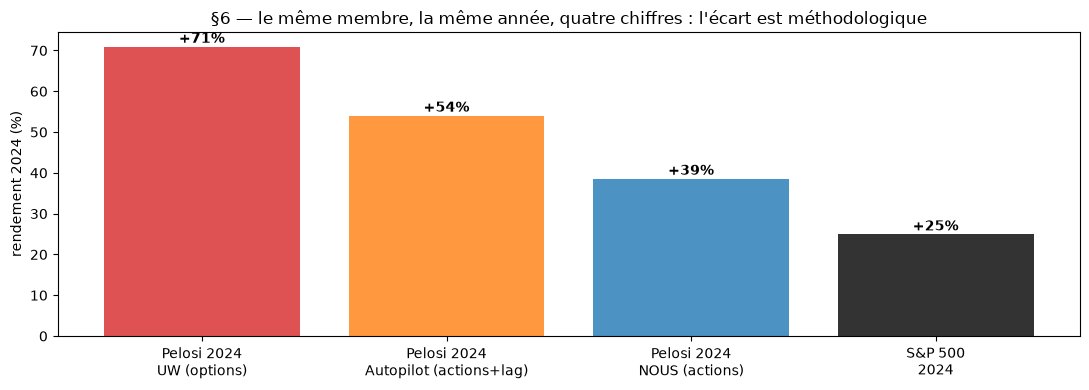

In [38]:
# barres appariées : la hype vs notre reconstruction
fig, ax = plt.subplots(figsize=(11, 4))
_lbl = ["Pelosi 2024\nUW (options)","Pelosi 2024\nAutopilot (actions+lag)","Pelosi 2024\nNOUS (actions)","S&P 500\n2024"]
_val = [0.709, 0.54, _pelosi_2024_actions, 0.249]
ax.bar(_lbl, [100*v for v in _val], color=["tab:red","tab:orange","tab:blue","k"], alpha=.8)
for i, v in enumerate(_val): ax.text(i, 100*v+1, f"{v:+.0%}", ha="center", fontweight="bold")
ax.set_ylabel("rendement 2024 (%)"); ax.set_title("§6 — le même membre, la même année, quatre chiffres : l'écart est méthodologique")
plt.tight_layout(); fig.savefig(FIG('K1_pelosi_4chiffres'), dpi=200, bbox_inches='tight', facecolor='white'); plt.show()

**K2 — Le paysage des benchmarks.**

⚠️ Chiffres **hétérogènes** (fenêtres, coûts, options incluses ou non) : c'est un *paysage marketing*, pas une
comparaison stricte.

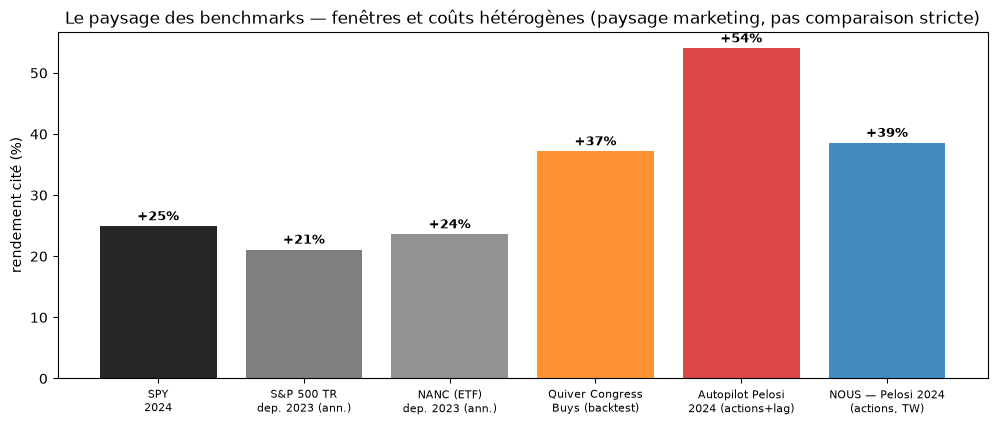

⚠ NANC/Quiver = annualisés (pas 2024) ; Autopilot/UW = 2024 ; à ne pas comparer strictement.


In [39]:
# K2 : paysage des benchmarks (rendements cités, fenêtres hétérogènes)
_pelosi24 = _pelosi_2024_actions  # notre reconstruction (§K1)
BENCH = [  # (label, valeur, fenêtre, couleur)
    ("SPY\n2024", 0.249, "année", "k"),
    ("S&P 500 TR\ndep. 2023 (ann.)", 0.2106, "annualisé", "dimgray"),
    ("NANC (ETF)\ndep. 2023 (ann.)", 0.2358, "annualisé", "tab:gray"),
    ("Quiver Congress\nBuys (backtest)", 0.3715, "annualisé", "tab:orange"),
    ("Autopilot Pelosi\n2024 (actions+lag)", 0.54, "année", "tab:red"),
    ("NOUS — Pelosi 2024\n(actions, TW)", _pelosi24, "année", "tab:blue"),
]
fig, ax = plt.subplots(figsize=(12, 4.5))
_x = range(len(BENCH))
ax.bar(_x, [100*v for _,v,_,_ in BENCH], color=[c for *_,c in BENCH], alpha=.85)
for i,(l,v,w,c) in enumerate(BENCH):
    ax.text(i, 100*v+1, f"{v:+.0%}", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(list(_x)); ax.set_xticklabels([l for l,*_ in BENCH], fontsize=8)
ax.set_ylabel("rendement cité (%)"); ax.axhline(0, color="k", lw=.6)
ax.set_title("Le paysage des benchmarks — fenêtres et coûts hétérogènes (paysage marketing, pas comparaison stricte)")
fig.savefig(FIG("K2_paysage_benchmarks"), dpi=200, bbox_inches="tight", facecolor="white"); plt.show()
print("⚠ NANC/Quiver = annualisés (pas 2024) ; Autopilot/UW = 2024 ; à ne pas comparer strictement.")

**T4 — Trackers & benchmarks au clair.**

In [40]:
# T4 : le tableau des benchmarks (source ETAT_DE_L_ART + HYPE)
T4 = pd.DataFrame([
    ["S&P 500 (SPY)", "indice", "réf.", "≈ marché", "oui", "0 %"],
    ["NANC", "ETF long Démocrates", "dep. 2023", "+23,6 %/an", "partiel (actions)", "0,72 %"],
    ["KRUZ / GOP", "ETF long Républicains", "dep. 2023", "n.c.", "partiel", "0,73–0,83 %"],
    ["Quiver « Congress Buys »", "backtest tracker", "backtest", "+37,1 %/an (β1,14)", "oui, sans coûts", "n.c."],
    ["Autopilot — Pelosi Tracker", "copy-trading", "2024", "+54 % (actions+lag)", "oui", "abonnement"],
    ["Unusual Whales — Pelosi", "tracker (options incl.)", "2024", "+70,9 %", "non (options)", "n.c."],
    ["NOUS — reconstruction", "actions seules, TW", "2014–2026", "Pelosi 2024 +38,5 %", "—", "—"],
], columns=["benchmark","type","fenêtre","rendement cité","réplicable chez nous ?","coûts"])
print("T4 — trackers & benchmarks", T4.shape)
display(T4)

T4 — trackers & benchmarks (7, 6)


,benchmark,type,fenêtre,rendement cité,réplicable chez nous ?,coûts
0,S&P 500 (SPY),indice,réf.,≈ marché,oui,0 %
1,NANC,ETF long Démocrates,dep. 2023,"+23,6 %/an",partiel (actions),"0,72 %"
2,KRUZ / GOP,ETF long Républicains,dep. 2023,n.c.,partiel,"0,73–0,83 %"
3,Quiver « Congress Buys »,backtest tracker,backtest,"+37,1 %/an (β1,14)","oui, sans coûts",n.c.
4,Autopilot — Pelosi Tracker,copy-trading,2024,+54 % (actions+lag),oui,abonnement
5,Unusual Whales — Pelosi,tracker (options incl.),2024,"+70,9 %",non (options),n.c.
6,NOUS — reconstruction,"actions seules, TW",2014–2026,"Pelosi 2024 +38,5 %",—,—


# Ce qu'on retient

- Population **ultra-concentrée** (2 membres = 41 % des trades), souvent via le **conjoint** (38 %),
  portefeuilles **concentrés** (plus grosse position ~45 %) et **tenus longtemps** (~1 an, 44 % jamais revendues).
- Des **portraits** très différents, des chiffres parfois spectaculaires — mais **aucun ne passe le seuil de
  significativité** : on décrit des personnes, pas un signal copiable.
- Le **paysage des benchmarks** est un affichage marketing : plus c'est réplicable (options retirées, coûts,
  time-weighting), plus le chiffre baisse — de +70,9 % (UW options) à **+38,5 %** (nous, actions).

*Figures exportées dans `docs/figs_pop/`. Deck autonome — à intégrer aux slides après validation.*